# MID Decay Modeling
This notebook focuses on the modeling phase using cleaned data from MID_Decay.ipynb

In [161]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [162]:
# Assuming df is your pooled dataframe with 'mid' and 'date' columns
# Sort the full df by mid and date
df = df.sort_values(['mid', 'date']).reset_index(drop=True)

# Define split ratios (adjust as needed)
train_p = 0.7
val_p = 0.15
test_p = 0.15  # Should sum to 1.0

# Initialize empty DFs for splits
train_df = pd.DataFrame()
val_df = pd.DataFrame()
test_df = pd.DataFrame()

# Get unique MIDs
unique_mids = df['mid'].unique()  # Note: using 'mid' as per your code snippet

# Loop over each MID
for mid in unique_mids:
    mid_df = df[df['mid'] == mid].sort_values('date')  # Ensure sorted by date within MID
    
    n_rows = len(mid_df)
    if n_rows < 3:  # Skip if too few rows for meaningful split
        continue
    
    # Calculate split indices (time-ordered: first 70%, next 15%, last 15%)
    train_end = int(n_rows * train_p)
    val_end = train_end + int(n_rows * val_p)
    
    # Split
    mid_train = mid_df.iloc[:train_end]
    mid_val = mid_df.iloc[train_end:val_end]
    mid_test = mid_df.iloc[val_end:]
    
    # Append to overall splits
    train_df = pd.concat([train_df, mid_train])
    val_df = pd.concat([val_df, mid_val])
    test_df = pd.concat([test_df, mid_test])

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Verify sizes
total_rows = len(df)
print(f"Train: {len(train_df)} rows ({len(train_df)/total_rows:.1%})")
print(f"Val: {len(val_df)} rows ({len(val_df)/total_rows:.1%})")
print(f"Test: {len(test_df)} rows ({len(test_df)/total_rows:.1%})")

# Now you can use train_df, val_df, test_df for modeling
# Example: X_train = train_df.drop(['success_charge_ratess', 'date', 'mid'], axis=1)
# etc.


Train: 7 rows (63.6%)
Val: 1 rows (9.1%)
Test: 3 rows (27.3%)


Error reading db_decay_60.csv: [Errno 2] No such file or directory: 'db_decay_60.csv'

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67681 entries, 0 to 67680
Data columns (total 72 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Merchant                            67681 non-null  object
 1   Item                                67681 non-null  object
 2   Card Type                           67681 non-null  object
 3   Transaction Day Of Week             67681 non-null  object
 4   Card Bin Number                     67681 non-null  int64 
 5   Ship State                          67680 non-null  object
 6   Attempted Charges                   67681 non-null  int64 
 7   Declined Charges                    67681 non-null  int64 
 8   Declined Charge Rate                67681 non-null  object
 9   Successful Charges                  67681 non-null  int64 
 10  Success Charge Ra

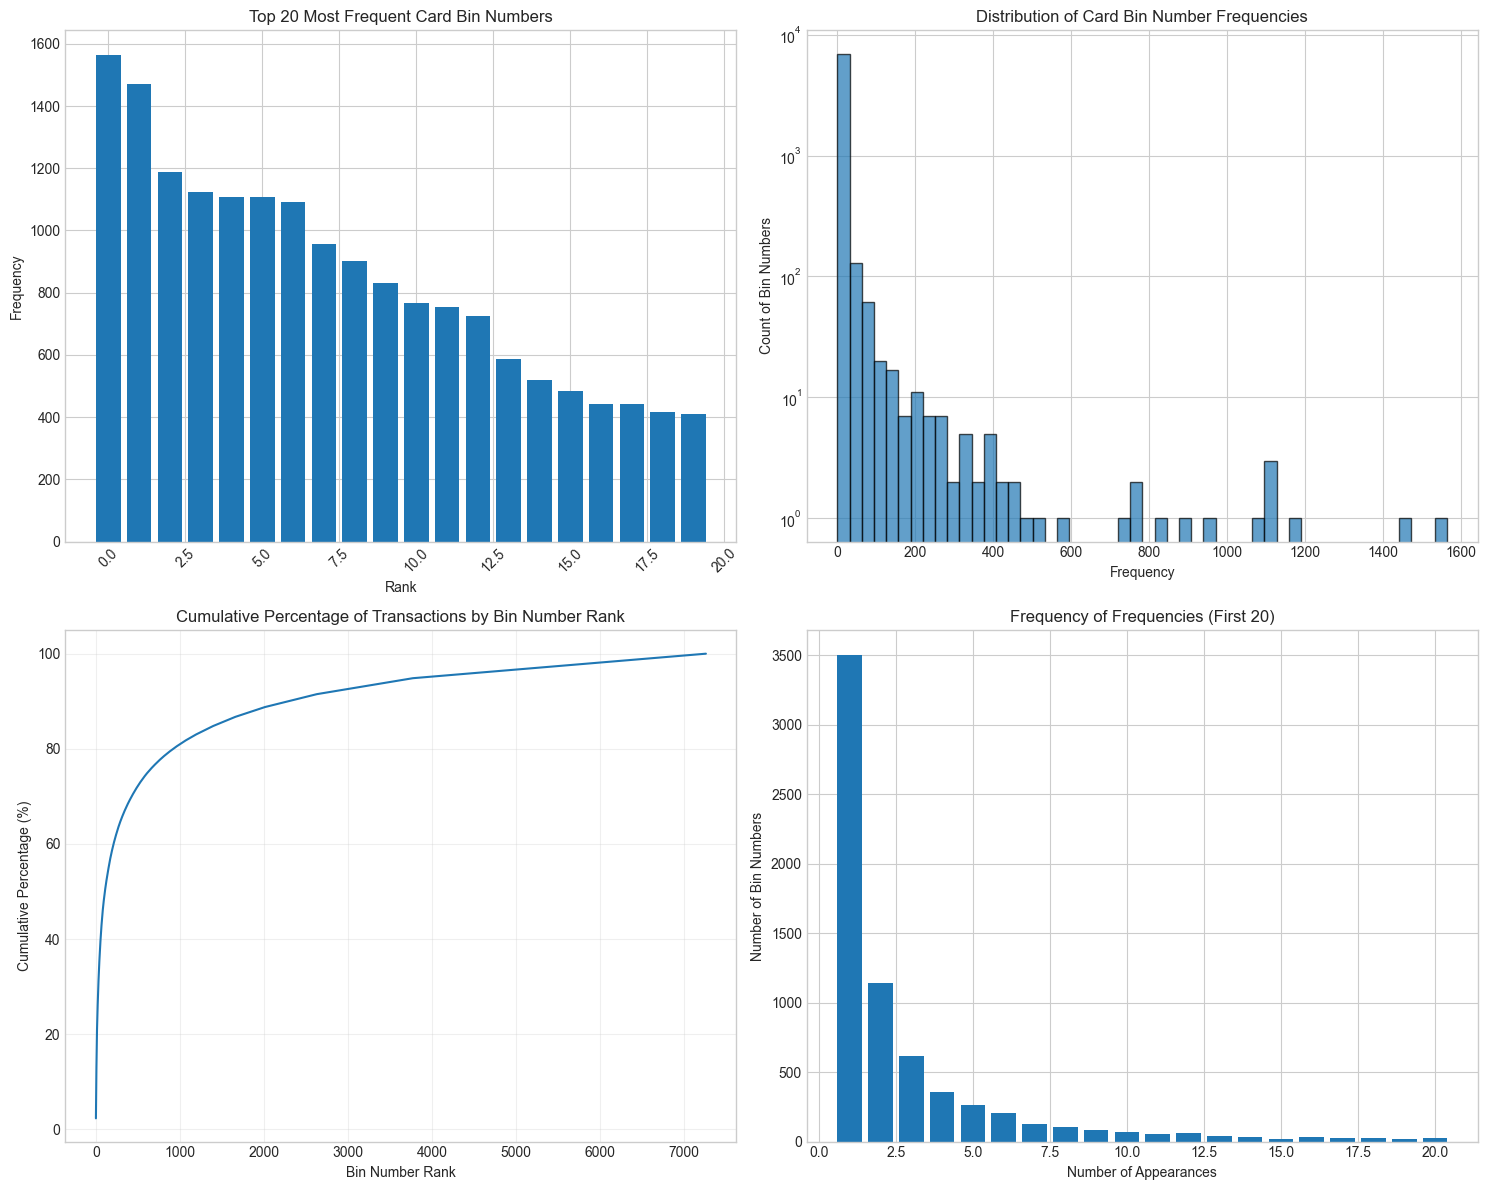


Coverage analysis:
Top 10 bin numbers cover: 16.76% of transactions
Top 50 bin numbers cover: 38.07% of transactions
Top 100 bin numbers cover: 48.92% of transactions
Top 500 bin numbers cover: 72.20% of transactions
BIN Database Info:
Shape: (374788, 10)
Columns: ['BIN', 'Brand', 'Type', 'Category', 'Issuer', 'IssuerPhone', 'IssuerUrl', 'isoCode2', 'isoCode3', 'CountryName']

First few rows of BIN database:
Total unique BINs in Decay_Data: 7262
Sample BINs from Decay_Data: [444796 401154 442326 510553 514616 516676 521333 526929 529149 539689]

Unique 6-digit BIN prefixes in Decay_Data: 7262

BIN database columns: ['BIN', 'Issuer']
Total BINs in BIN database: 374788

=== MATCHING RESULTS ===
BINs with matches: 7256
BINs without matches: 6
Match rate: 99.92%

Sample matched BINs: ['546208', '544951', '442779', '442505', '419028', '429609', '510380', '518203', '485638', '485932']
Sample unmatched BINs: ['512148', '534474', '517809', '559659', '514032', '521999']

=== TRANSACTION COVERA

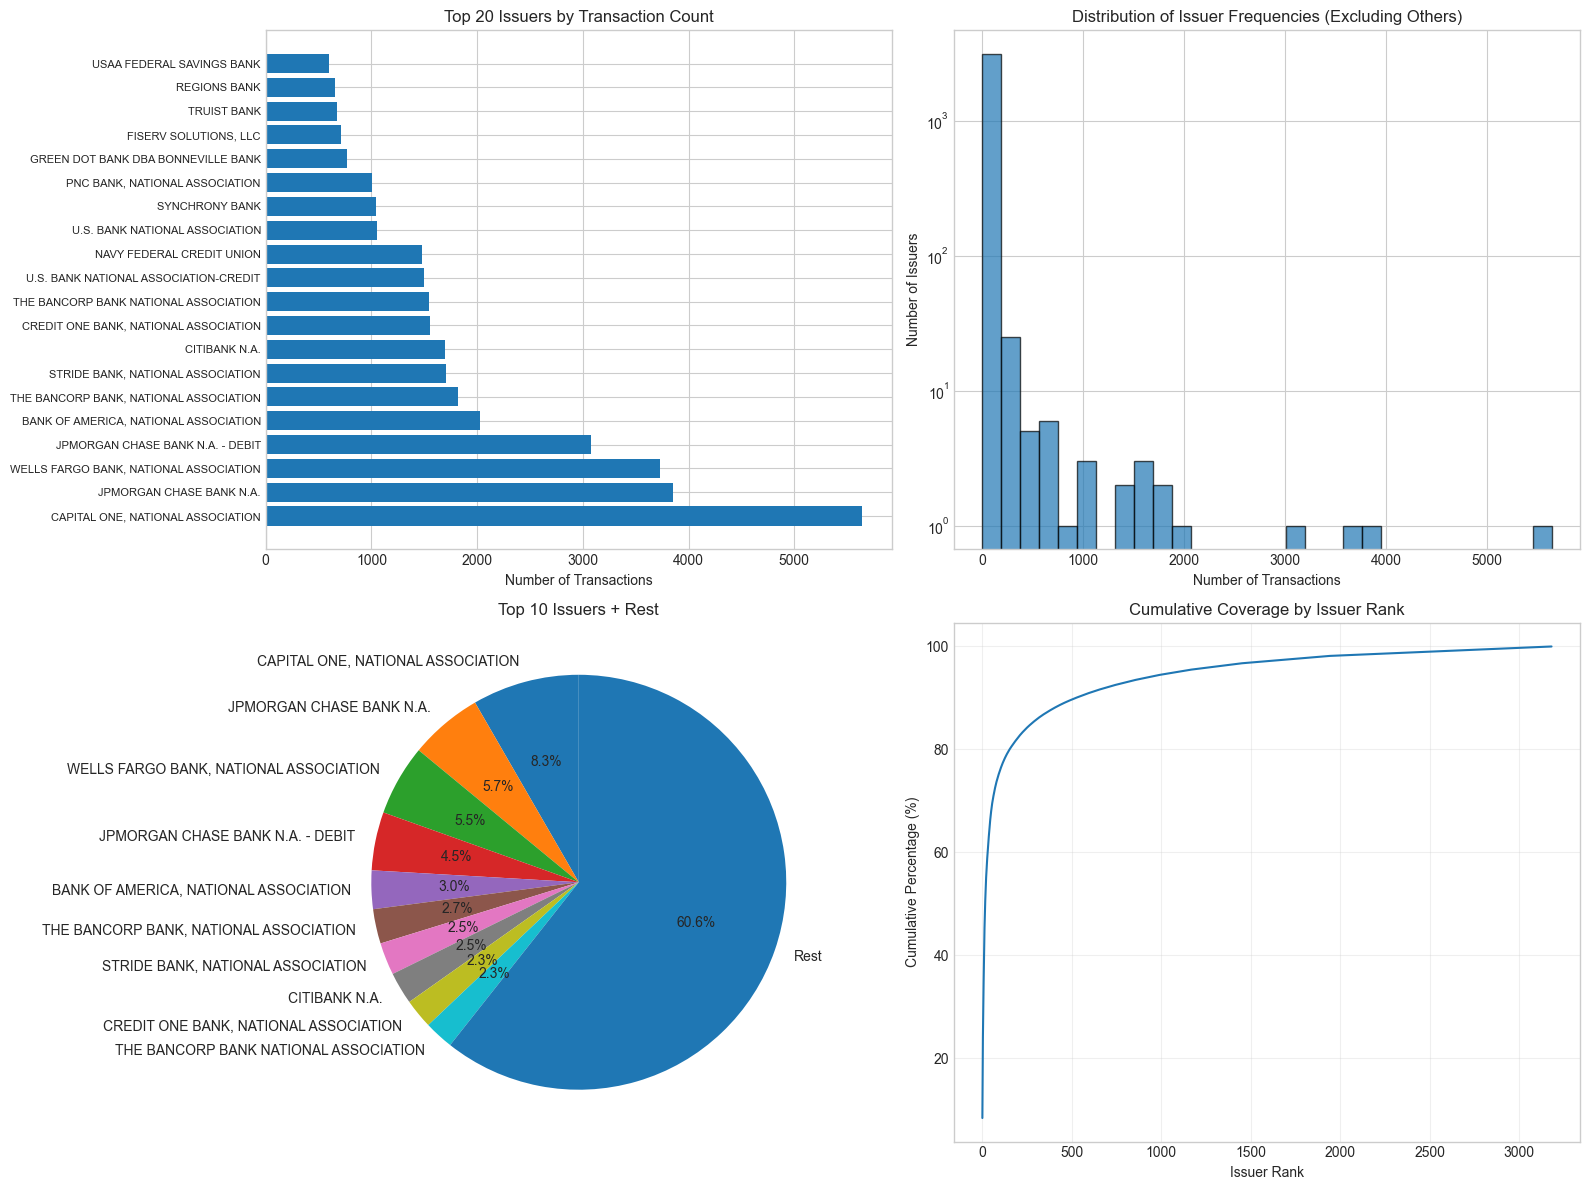


=== SUMMARY ===
Total unique issuers found: 3182
Top 10 issuers cover: 39.36% of transactions
Top 20 issuers cover: 53.37% of transactions
'Others' category: 0.01% of transactions


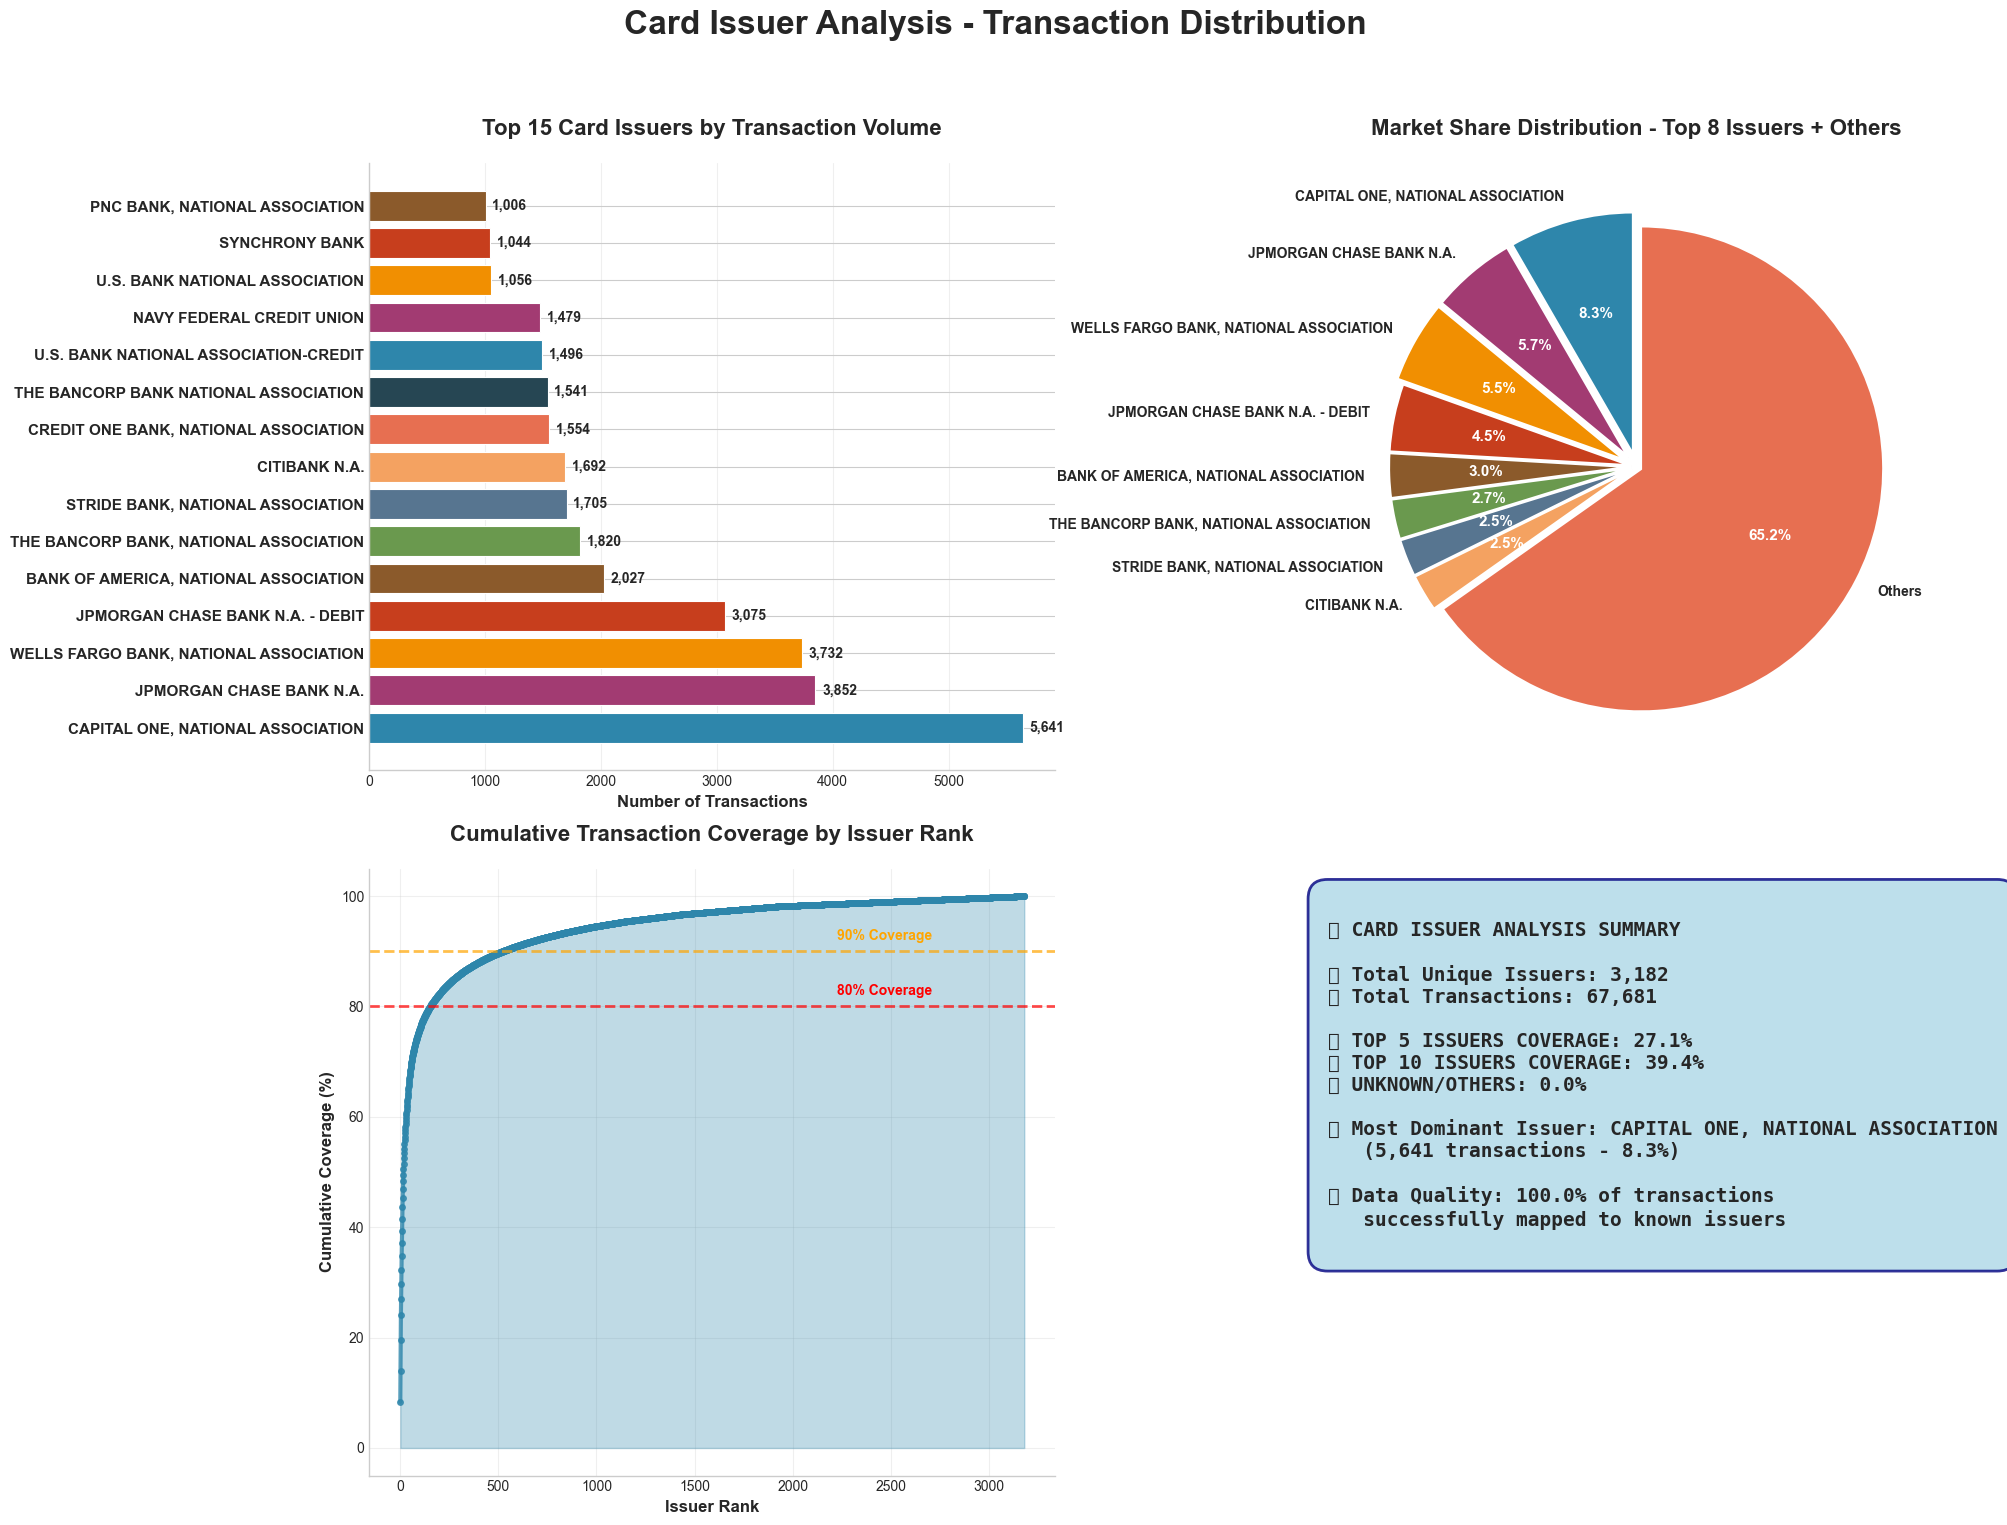

🏦 EXECUTIVE SUMMARY - CARD ISSUER DISTRIBUTION
📊 Dataset Overview:
   • Total Transactions: 67,681
   • Unique Card Issuers: 3182
   • Data Completeness: 100.0%

💼 Market Concentration:
   • Top 3 Issuers: 19.5% of transactions
   • Top 5 Issuers: 27.1% of transactions
   • Top 10 Issuers: 39.4% of transactions

🏆 Leading Issuers:
   1. CAPITAL ONE, NATIONAL ASSOCIATION: 5,641 transactions (8.3%)
   2. JPMORGAN CHASE BANK N.A.: 3,852 transactions (5.7%)
   3. WELLS FARGO BANK, NATIONAL ASSOCIATION: 3,732 transactions (5.5%)
   4. JPMORGAN CHASE BANK N.A. - DEBIT: 3,075 transactions (4.5%)
   5. BANK OF AMERICA, NATIONAL ASSOCIATION: 2,027 transactions (3.0%)
The length of the bin_database is (7256, 2)
The number of unique BINs in the bin_database is 7256
=== CREATING BANK_ISSUER COLUMN USING BIN DATABASE MAPPING ===
Mapping BIN numbers to bank issuers using bin_database_dict...
Starting loop over 67,681 rows...
Processed 10,000 rows...
Processed 20,000 rows...
Processed 30,000 rows...


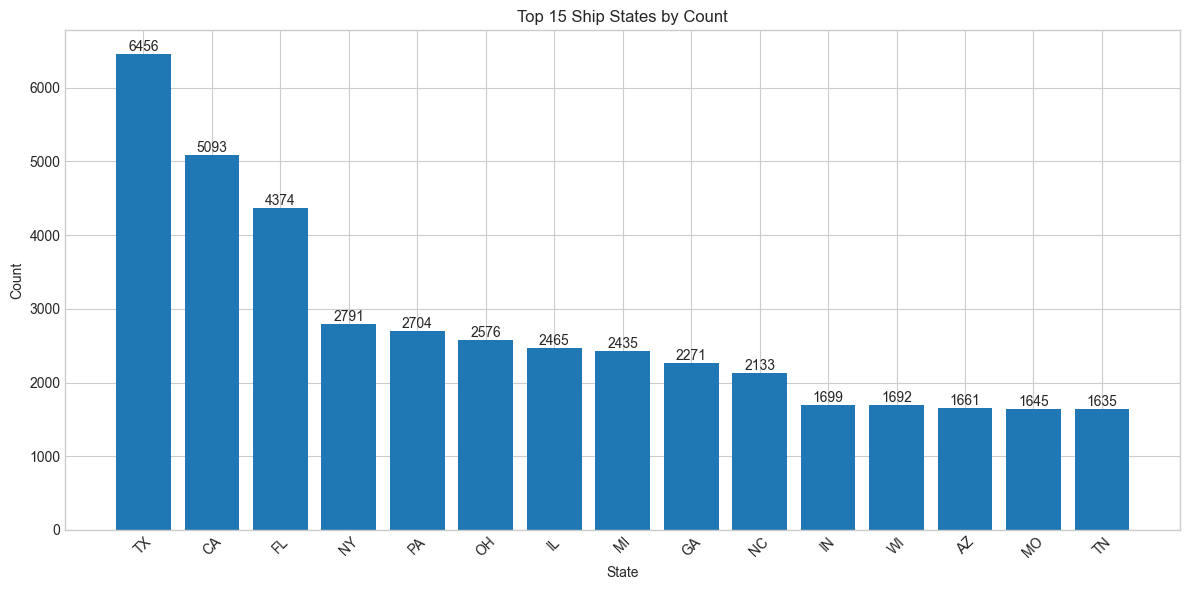

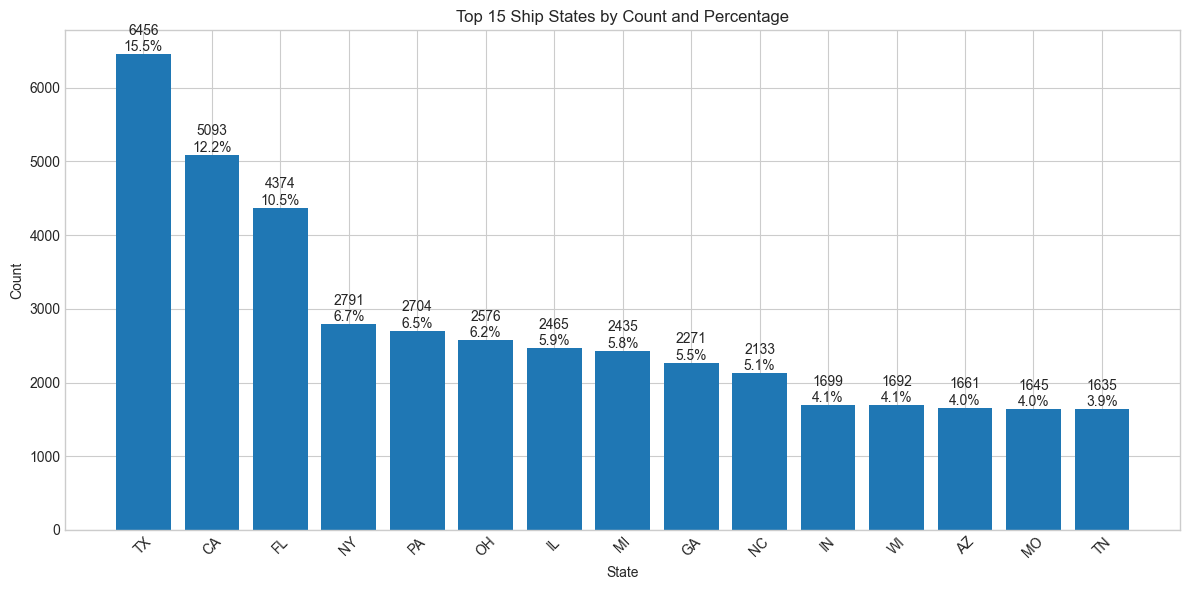

Before update:
Unique ship_state values: 54
Values in dict_ship_state: ['TX', 'CA', 'FL', 'NY', 'PA', 'OH', 'IL', 'MI', 'GA', 'NC', 'IN', 'WI', 'AZ', 'MO', 'TN']
Sample current values: ship_state
TX    6456
CA    5093
FL    4374
NY    2791
PA    2704
Name: count, dtype: int64

After update:
Updated ship_state value counts:
ship_state
OTHER    26051
TX        6456
CA        5093
FL        4374
NY        2791
PA        2704
OH        2576
IL        2465
MI        2435
GA        2271
NC        2133
IN        1699
WI        1692
AZ        1661
MO        1645
TN        1635
Name: count, dtype: int64

Total 'OTHER' values: 26051
Percentage of OTHER values: 38.49%
Unique ship states in dataset:
['CA' 'FL' 'WI' 'TN' 'TX' 'NC' 'OTHER' 'OH' 'MI' 'NY' 'GA' 'PA' 'MO' 'IN'
 'IL' 'AZ']

Total unique ship states: 16

Ship states as set: {'NY', 'FL', 'NC', 'OH', 'PA', 'MO', 'IN', 'OTHER', 'TN', 'WI', 'MI', 'IL', 'CA', 'GA', 'AZ', 'TX'}

Added 16 shipstate columns to Decay_Data
New shipstate columns: [

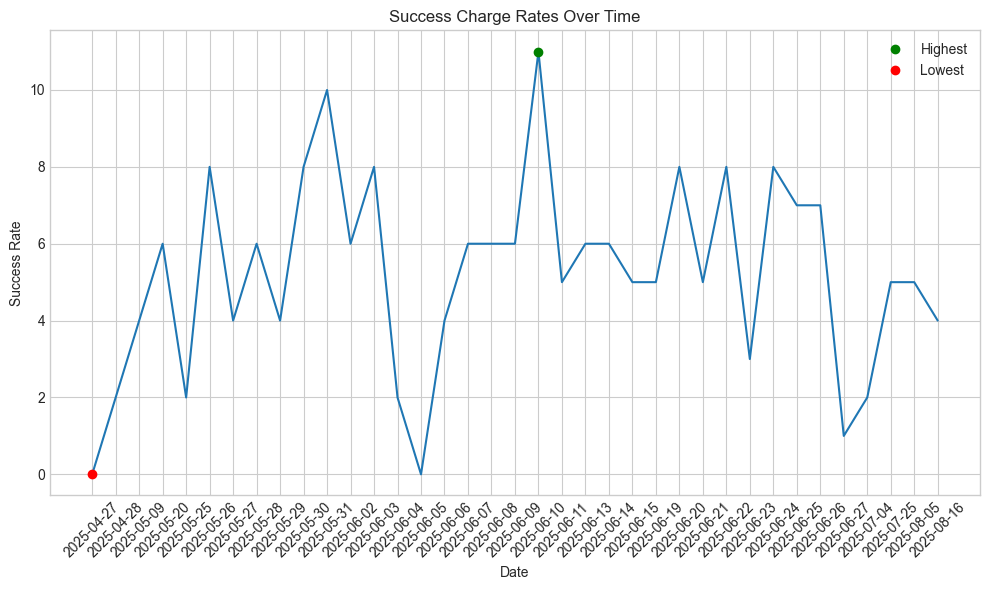

Highest success rate: 1.000 on 2025-06-04
Lowest success rate: 0.000 on 2025-04-27


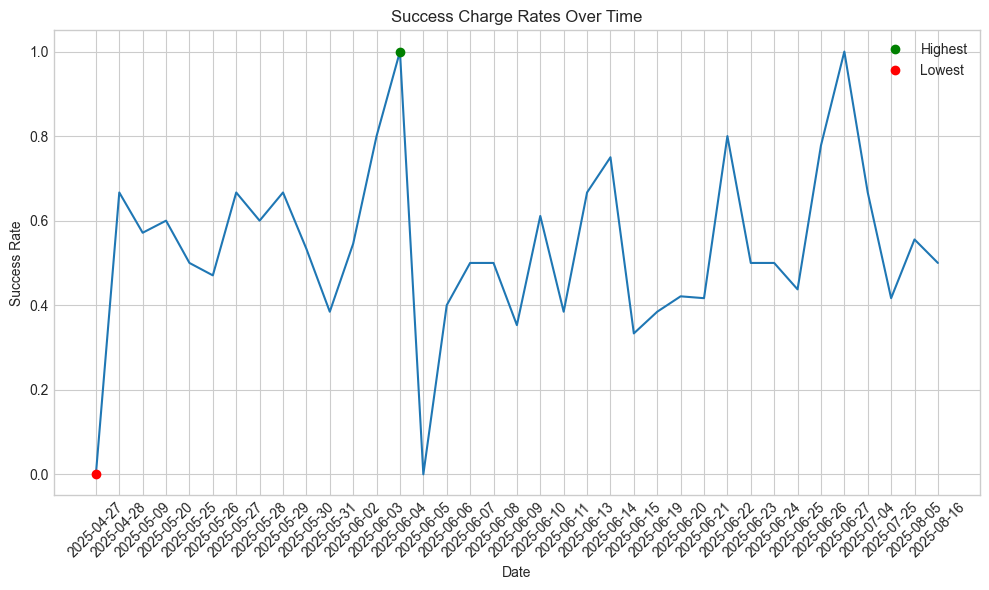

Original shape: (37, 119)
Shape after dropping one-hot columns and date: (37, 55)


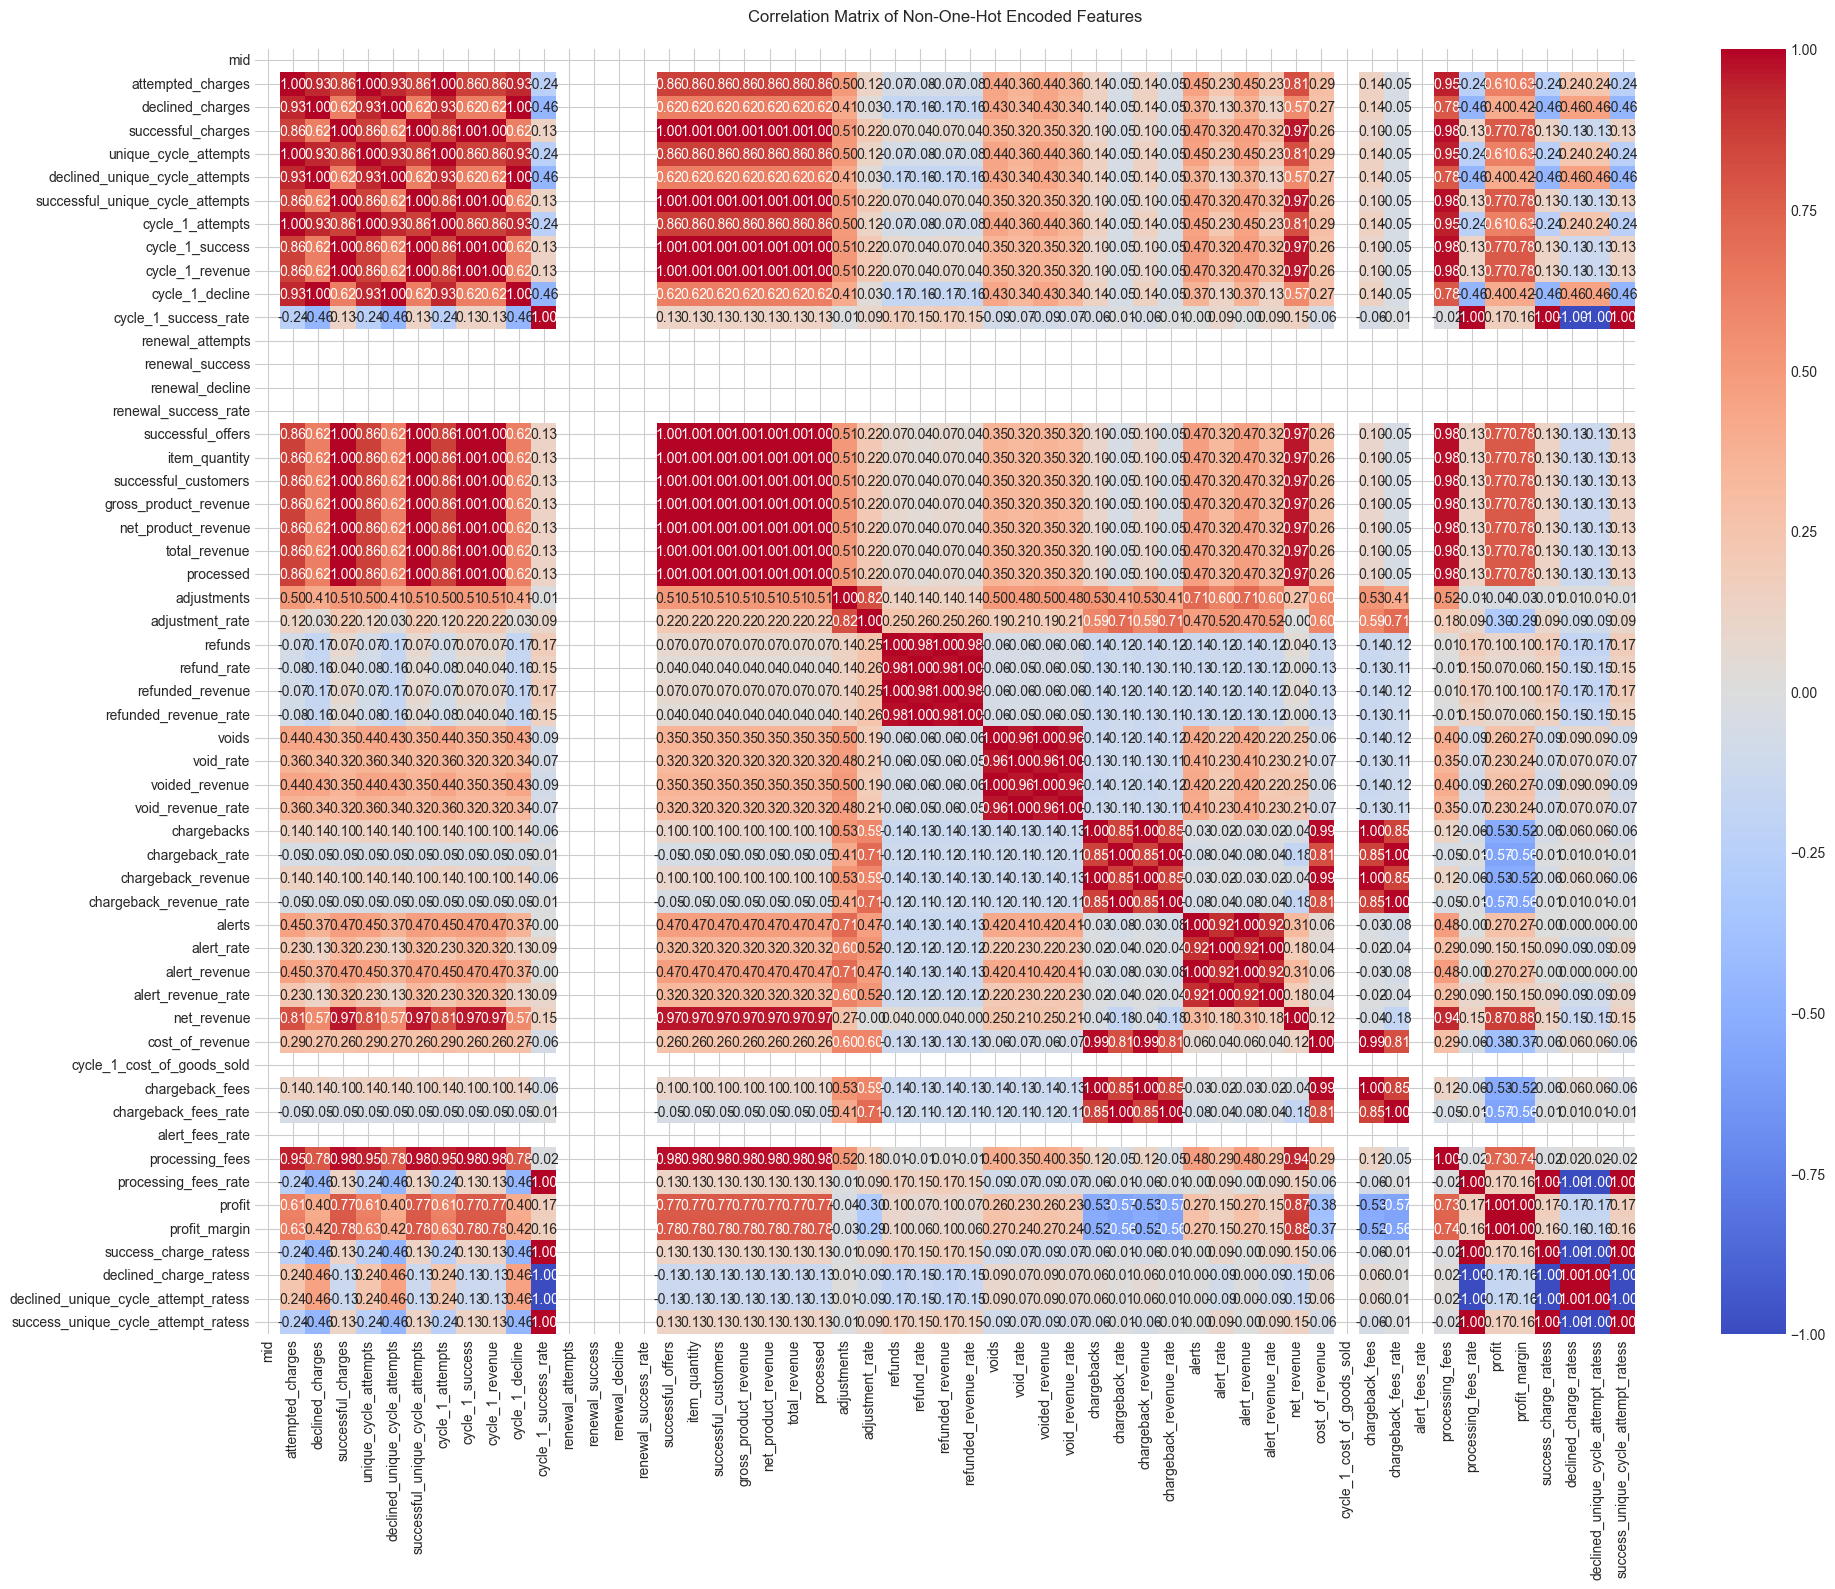

MAE: 0.00014322916666666824
R2: 0.9999987737440964

Top 25 features by absolute coefficient value:


cycle_1_success_rate                    2.072457e-01
processing_fees_rate                    1.471105e-15
declined_charge_ratess                 -1.973996e-18
declined_unique_cycle_attempt_ratess   -5.682715e-19
cycle_1_revenue                         0.000000e+00
chargeback_revenue_rate                -0.000000e+00
profit_margin                           0.000000e+00
profit                                  0.000000e+00
processing_fees                         0.000000e+00
chargeback_fees_rate                   -0.000000e+00
chargeback_fees                        -0.000000e+00
cost_of_revenue                        -0.000000e+00
net_revenue                             0.000000e+00
alert_revenue_rate                      0.000000e+00
alert_revenue                           0.000000e+00
alert_rate                              0.000000e+00
chargeback_revenue                     -0.000000e+00
chargeback_rate                        -0.000000e+00
void_revenue_rate                      -0.0000

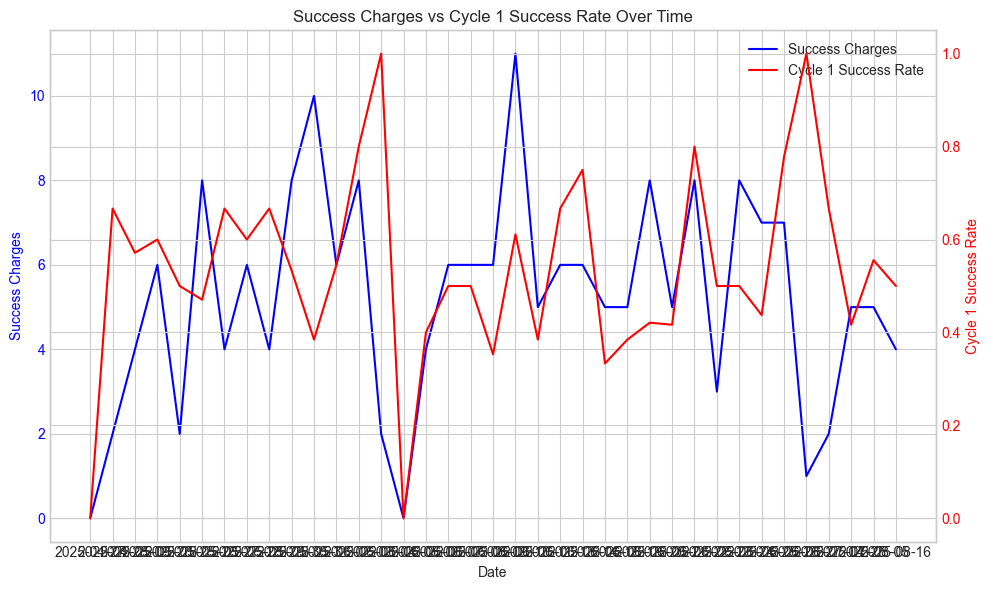


Correlation between Success Charges and Cycle 1 Success Rate: 0.129
Lag Testing Script Ready!
To run experiments, call: run_lag_experiments(your_test_dataframe)
=== BASELINE PERFORMANCE ===
RÂ²: 0.9999987737
MAE: 0.000143229166667

PHASE 1: Testing Individual Lag Periods

--- Testing Lag Period: 1 days ---
Creating lag features for 9 variables across 1 lag periods...
Processing lag period: 1 days...
Lag feature creation complete!
Original rows: 37, Final rows: 36
Rows dropped due to lagging: 1
Dropping 3 near-zero variance features
Training set: (28, 35), Test set: (8, 35)
RÂ²: 0.9999988584
MAE: 0.000143229166667
RMSE: 0.000199060869232
Number of features: 35
Non-zero coefficients: 4
RÂ² vs Baseline: +0.0000000846
MAE vs Baseline: +0.000000000000000

Top 5 Features:
  1. cycle_1_success_rate: 1.85911470e-01
  2. processing_fees_rate: 2.79966814e-05
  3. declined_charge_ratess: -9.29316148e-20
  4. declined_unique_cycle_attempt_ratess: -6.19544099e-20
  5. alert_revenue_rate: 0.0000000

processing_fees_rate                    0.186922
declined_charge_ratess                  0.185058
cycle_1_success_rate                    0.178912
declined_unique_cycle_attempt_ratess    0.171524
success_unique_cycle_attempt_ratess     0.162616
cost_of_revenue                         0.028960
processing_fees                         0.017818
net_product_revenue                     0.013061
net_revenue                             0.012555
gross_product_revenue                   0.010244
total_revenue                           0.008044
cycle_1_revenue                         0.008018
processed                               0.006889
profit                                  0.003665
profit_margin                           0.003451
adjustment_rate                         0.001192
adjustments                             0.000603
alert_revenue_rate                      0.000179
alert_rate                              0.000173
alert_revenue                           0.000055
chargeback_revenue_r

Creating Random Forest visualizations...


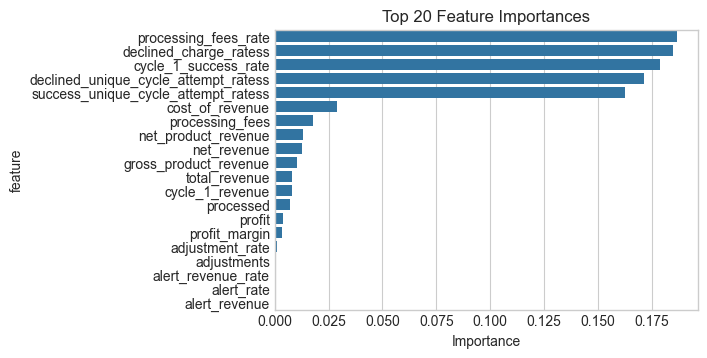

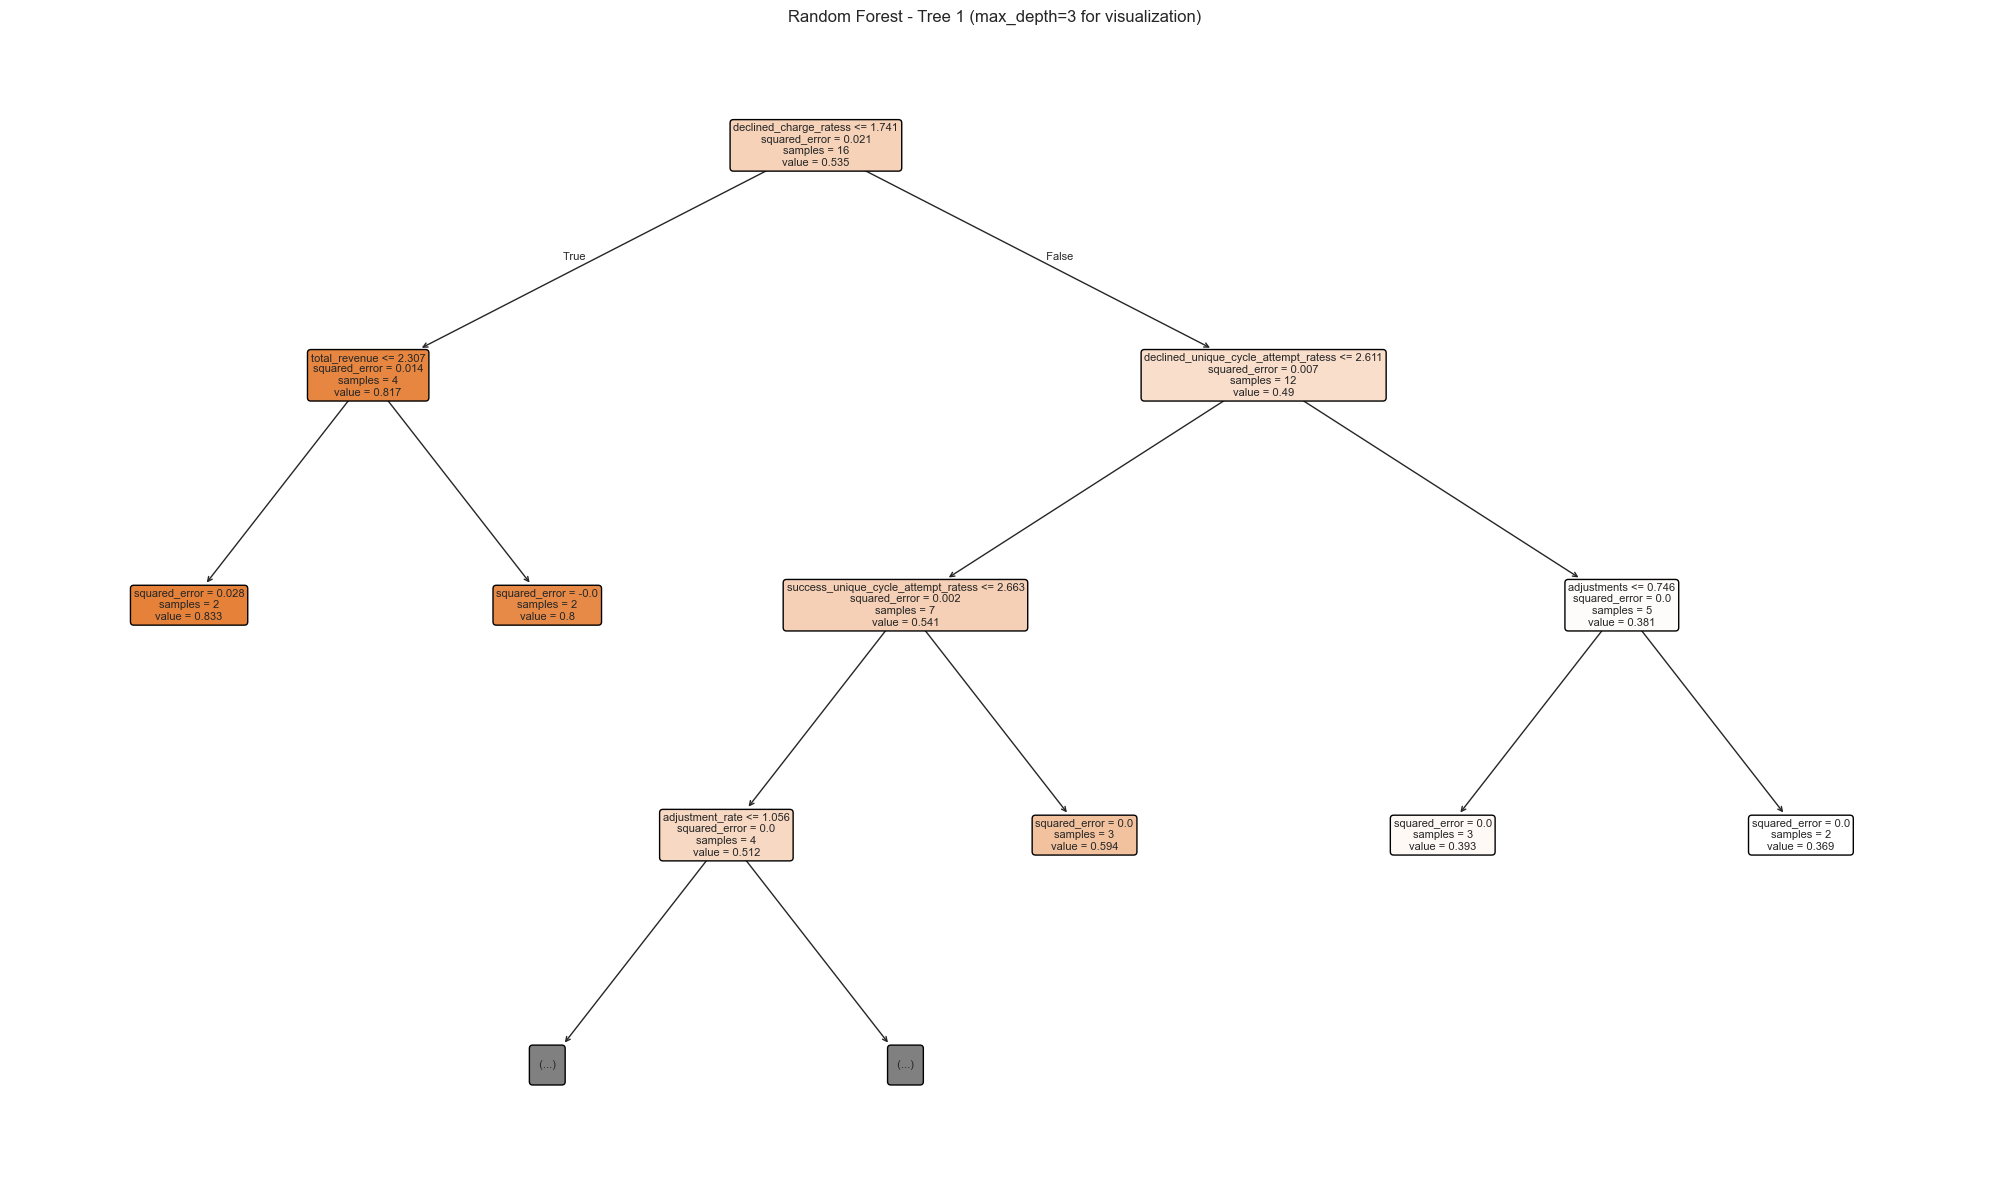

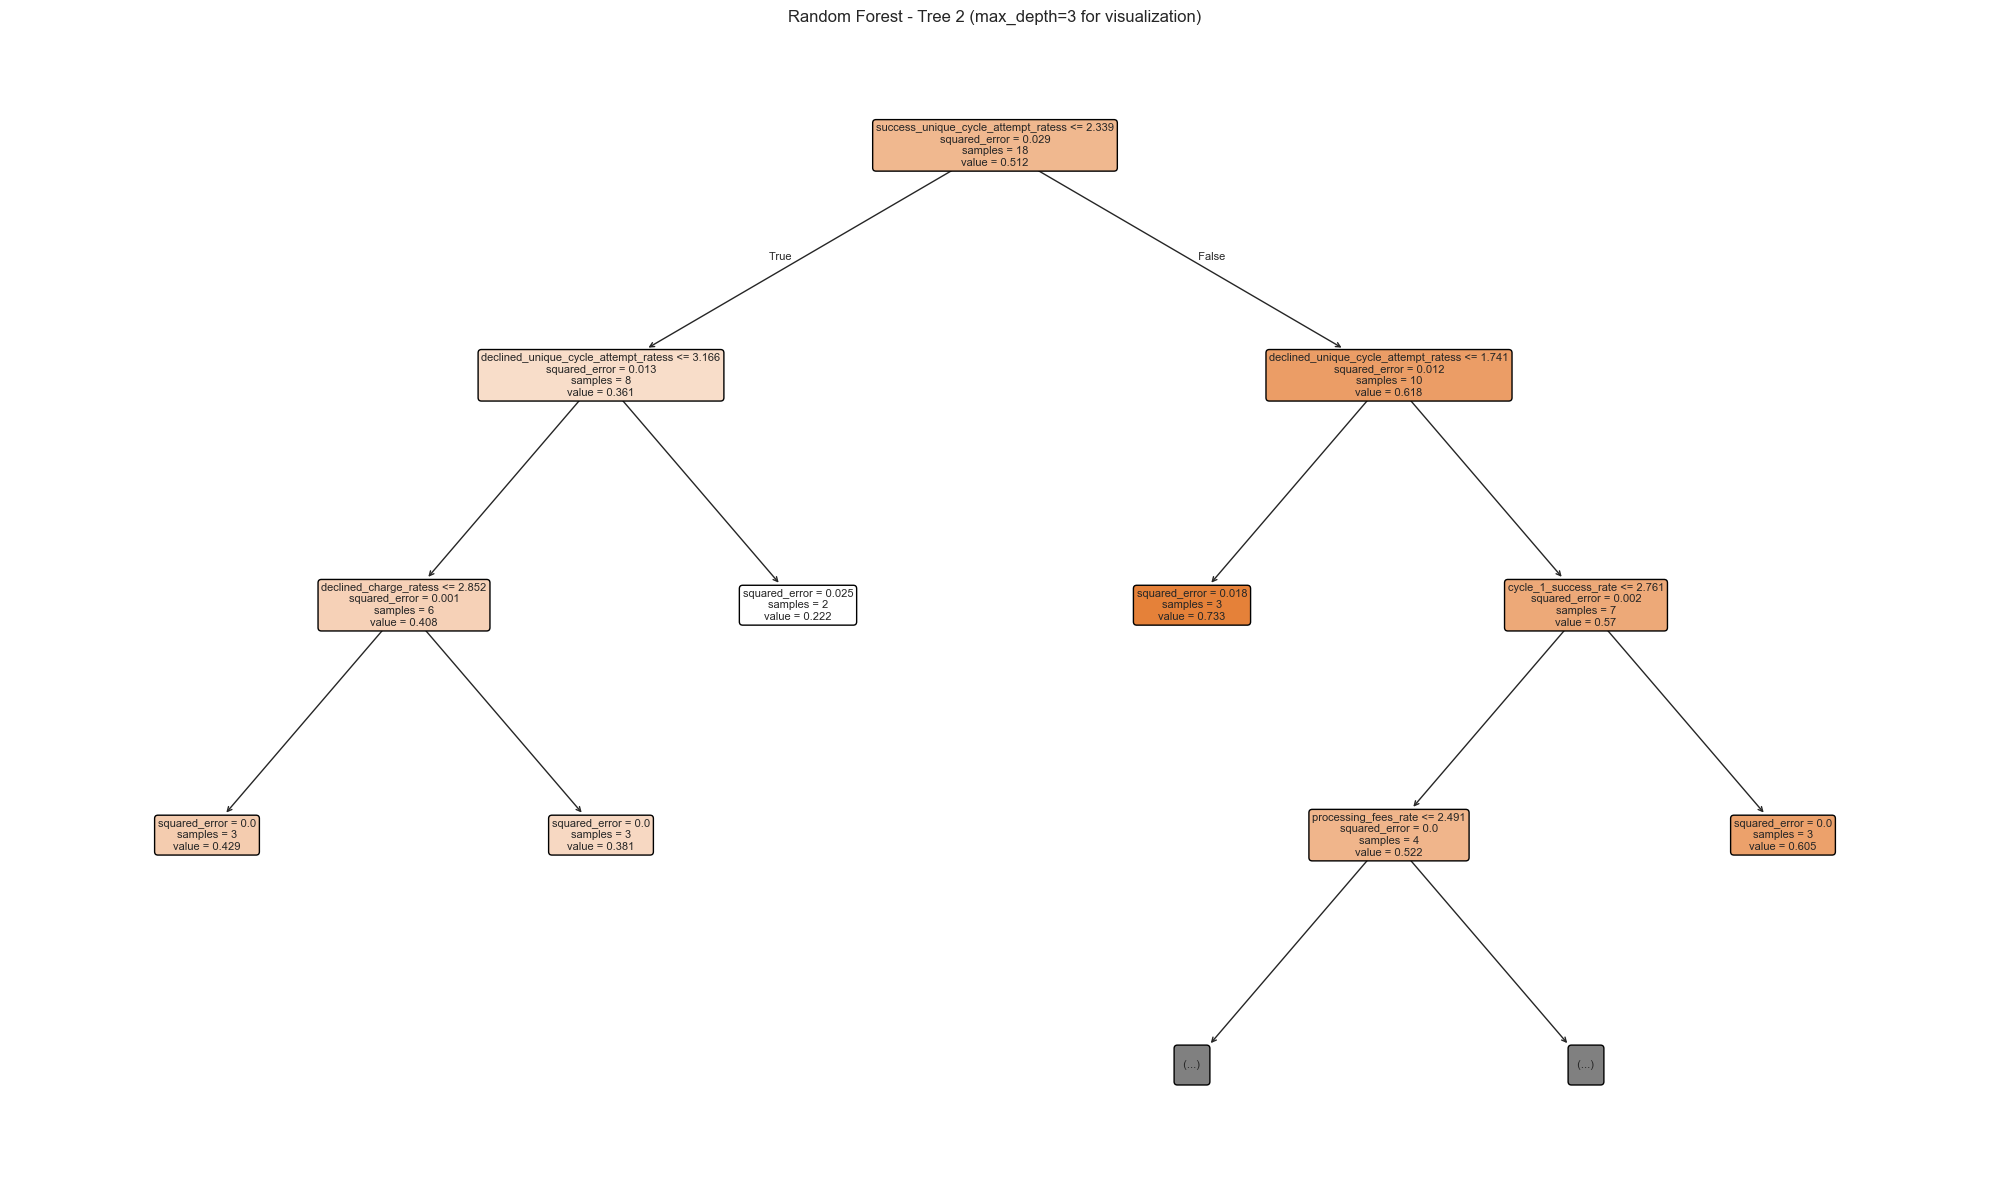

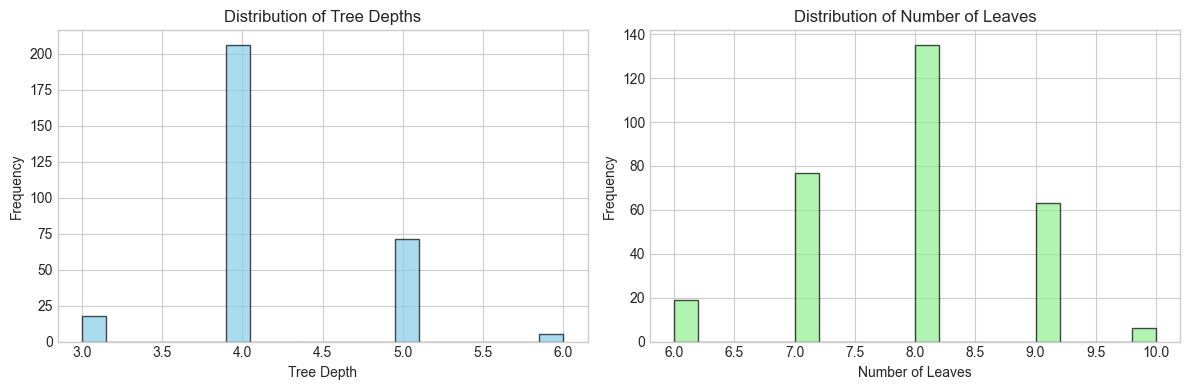

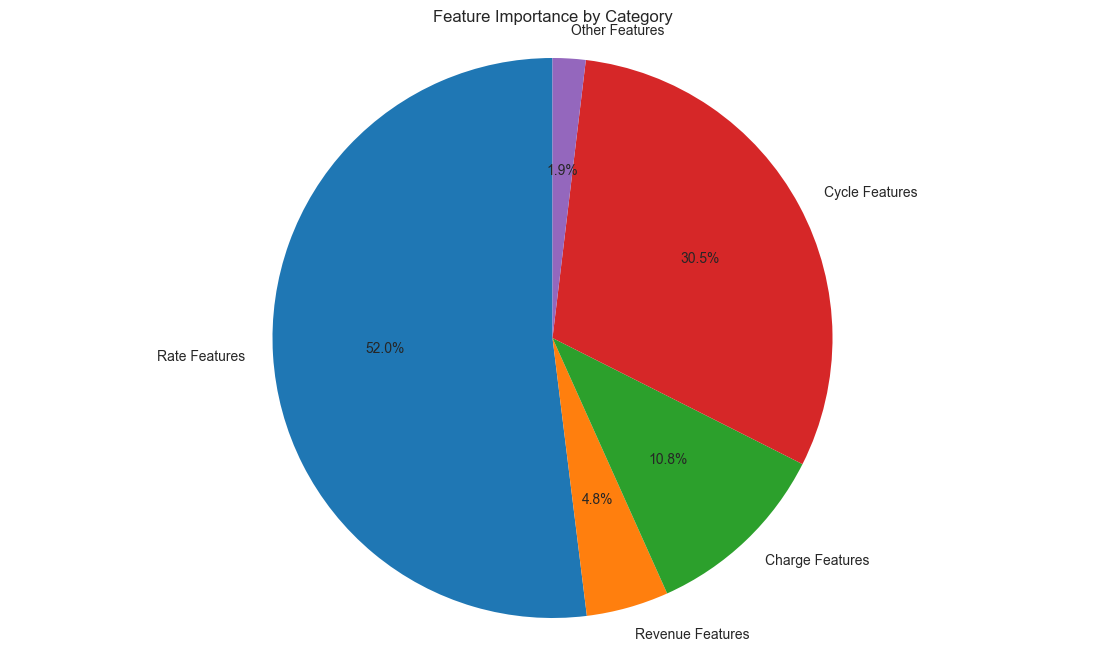

\n============================================================
TEXT REPRESENTATION OF FIRST TREE:
|--- declined_charge_ratess <= 1.74
|   |--- total_revenue <= 2.31
|   |   |--- value: [0.83]
|   |--- total_revenue >  2.31
|   |   |--- value: [0.80]
|--- declined_charge_ratess >  1.74
|   |--- declined_unique_cycle_attempt_ratess <= 2.61
|   |   |--- success_unique_cycle_attempt_ratess <= 2.66
|   |   |   |--- adjustment_rate <= 1.06
|   |   |   |   |--- value: [0.50]
|   |   |   |--- adjustment_rate >  1.06
|   |   |   |   |--- value: [0.52]
|   |   |--- success_unique_cycle_attempt_ratess >  2.66
|   |   |   |--- value: [0.59]
|   |--- declined_unique_cycle_attempt_ratess >  2.61
|   |   |--- adjustments <= 0.75
|   |   |   |--- value: [0.39]
|   |   |--- adjustments >  0.75
|   |   |   |--- value: [0.37]

\n============================================================
RANDOM FOREST MODEL STATISTICS:
Number of trees: 300
Average tree depth: 4.21
Max tree depth: 6
Min tree depth: 3
Ave

cycle_1_success_rate                    0.62509
cycle_1_revenue                         0.37491
chargeback_revenue_rate                 0.00000
declined_unique_cycle_attempt_ratess    0.00000
declined_charge_ratess                  0.00000
profit_margin                           0.00000
profit                                  0.00000
processing_fees_rate                    0.00000
processing_fees                         0.00000
chargeback_fees_rate                    0.00000
chargeback_fees                         0.00000
cost_of_revenue                         0.00000
net_revenue                             0.00000
alert_revenue_rate                      0.00000
alert_revenue                           0.00000
alert_rate                              0.00000
chargeback_revenue                      0.00000
chargeback_rate                         0.00000
void_revenue_rate                       0.00000
voided_revenue                          0.00000
void_rate                               

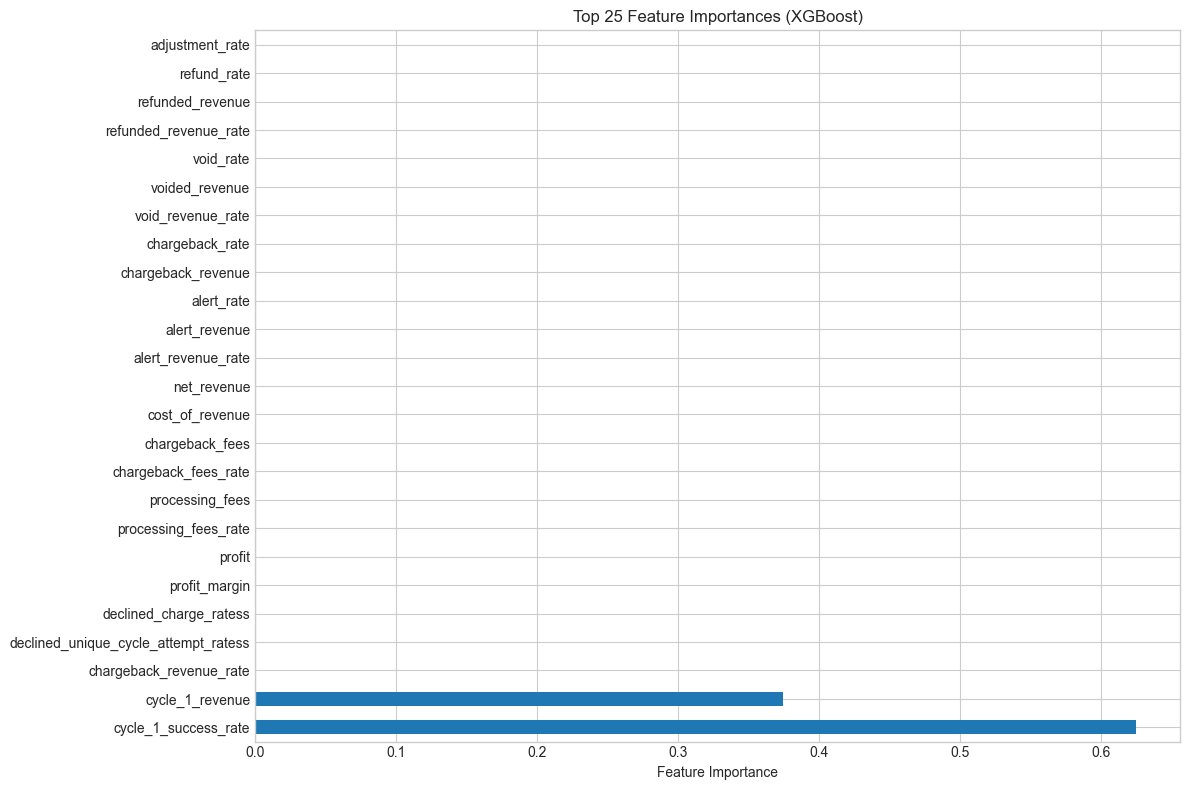


Final model details:
Number of estimators: 300
Max depth: 3
Learning rate: 0.2
Subsample: 1.0
The average day duration of the mids here are 107.44 
The standard deviation of the day durations of the mids here is 30.95
The average sales of the mids here is 287.99
The standard deviation of the sales of the mids here is 241.09


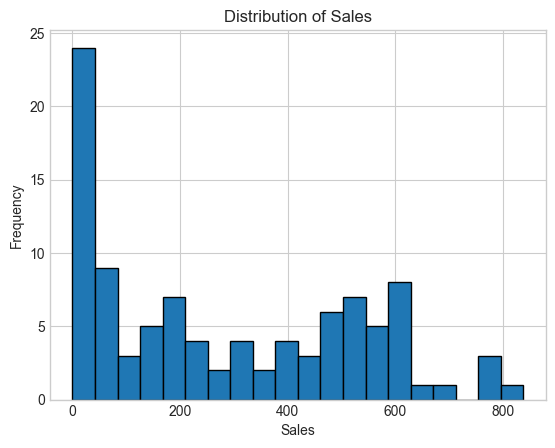

In [163]:
# Import objects from MID_Decay.ipynb
%run MID_Decay.ipynb

In [164]:
# Verify imported data
print("Available dataframes:")
print(f"mid_dataframes_uncleaned type: {type(mid_dataframes_uncleaned)}")
if isinstance(mid_dataframes_uncleaned, dict):
    print(f"Keys: {list(mid_dataframes_uncleaned.keys())}")
elif isinstance(mid_dataframes_uncleaned, pd.DataFrame):
    print(f"Shape: {mid_dataframes_uncleaned.shape}")
    print(f"Columns: {mid_dataframes_uncleaned.columns.tolist()}")

Available dataframes:
mid_dataframes_uncleaned type: <class 'dict'>
Keys: ['17_df', '20_df', '21_df', '22_df', '23_df', '26_df', '33_df', '8_df', '10_df', '11_df', '12_df', '13_df', '14_df', '18_df', '19_df', '25_df', '27_df', '28_df', '29_df', '3_df', '30_df', '31_df', '35_df', '37_df', '39_df', '43_df', '44_df', '46_df', '47_df', '48_df', '49_df', '5_df', '50_df', '51_df', '52_df', '53_df', '54_df', '56_df', '57_df', '58_df', '59_df', '6_df', '61_df', '62_df', '63_df', '64_df', '67_df', '68_df', '69_df', '7_df', '72_df', '73_df', '75_df', '9_df', '100_df', '101_df', '103_df', '105_df', '106_df', '2_df', '24_df', '32_df', '34_df', '4_df', '40_df', '45_df', '60_df', '65_df', '66_df', '70_df', '77_df', '81_df', '92_df', '93_df', '94_df', '96_df', '99_df', '102_df', '41_df', '91_df', '95_df', '104_df', '107_df', '36_df', '38_df', '42_df', '55_df', '74_df', '110_df', '111_df', '112_df', '76_df', '15_df', '16_df', '71_df', '87_df', '86_df', '97_df', '98_df']


## Data Preparation for Modeling

In [165]:
test = mid_dataframes_uncleaned["20_df"]
test

,date,mid,attempted_charges,declined_charges,successful_charges,unique_cycle_attempts,declined_unique_cycle_attempts,successful_unique_cycle_attempts,cycle_1_attempts,cycle_1_success,cycle_1_revenue,cycle_1_decline,cycle_1_success_rate,renewal_attempts,renewal_success,renewal_decline,renewal_success_rate,successful_offers,item_quantity,successful_customers,gross_product_revenue,net_product_revenue,total_revenue,processed,adjustments,adjustment_rate,refunds,refund_rate,refunded_revenue,refunded_revenue_rate,voids,void_rate,voided_revenue,void_revenue_rate,chargebacks,chargeback_rate,chargeback_revenue,chargeback_revenue_rate,alerts,alert_rate,alert_revenue,alert_revenue_rate,net_revenue,cost_of_revenue,cycle_1_cost_of_goods_sold,chargeback_fees,chargeback_fees_rate,alert_fees_rate,processing_fees,processing_fees_rate,profit,profit_margin,processor_psf_pnc,processor_esq,processor_merchantindustries,processor_signa_esq,processor_bbva,processor_apps_syn,processor_72_psf,processor_cbsl,processor_prior_syn,processor_signapay,processor_payarc_evo,processor_net_esq,processor_evo,processor_quant_cbsl,processor_cbc,processor_syn,processor_psf_bbva,processor_71_psf,SpecifiConLLC,DiamondsphereLLC,DiamondSphereLLC,PrimeSmartSolutionsLLC,ClearPoulseLLC,BrightAdvantageLLC,BrightAdvantagellc,UniquePlusLLC,charge_dp1_v3,charge_dp1_v1,cardtype_visa,cardtype_mastercard,dayofweek_thursday,dayofweek_monday,dayofweek_sunday,dayofweek_tuesday,dayofweek_wednesday,dayofweek_saturday,dayofweek_friday,bankissuer_the_bancorp_bank_national_association,bankissuer_jpmorgan_chase_bank_na,bankissuer_other,bankissuer_stride_bank_national_association,bankissuer_capital_one_national_association,bankissuer_bank_of_america_national_association,bankissuer_wells_fargo_bank_national_association,bankissuer_jpmorgan_chase_bank_na_-_debit,bankissuer_citibank_na,bankissuer_credit_one_bank_national_association,shipstate_ny,shipstate_fl,shipstate_nc,shipstate_oh,shipstate_pa,shipstate_mo,shipstate_in,shipstate_other,shipstate_tn,shipstate_wi,shipstate_mi,shipstate_il,shipstate_ca,shipstate_ga,shipstate_az,shipstate_tx,success_charge_ratess,declined_charge_ratess,declined_unique_cycle_attempt_ratess,success_unique_cycle_attempt_ratess
1,2025-04-27,20,1,1,0,1,1,0,1,0,0.00,1,0.0,0,0,0,0.0,0,0,0,0.00,0.00,0.00,0.00,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.00,0.20,0.0,0.0,0.0,0.0,0.20,0.0000,-0.20,0.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,1.0,1.0,0.0
2,2025-04-27,20,1,1,0,1,1,0,1,0,0.00,1,0.0,0,0,0,0.0,0,0,0,0.00,0.00,0.00,0.00,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.00,0.20,0.0,0.0,0.0,0.0,0.20,0.0000,-0.20,0.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.0,1.0,1.0,0.0
204,2025-04-28,20,1,1,0,1,1,0,1,0,0.00,1,0.0,0,0,0,0.0,0,0,0,0.00,0.00,0.00,0.00,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.00,0.20,0.0,0.0,0.0,0.0,0.20,0.0000,-0.20,0.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0.0,1.0,1.0,0.0
205,2025-04-28,20,1,0,1,1,0,1,1,1,12.89,0,1.0,0,0,0,0.0,1,1,1,12.89,12.89,12.89,12.89,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,12.89,0.84,0.0,0.0,0.0,0.0,0.84,0.0652,12.05,0.9348,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1.0,0.0,0.0,1.0
206,2025-04-28,20,1,0,1,1,0,1,1,1,12.89,0,1.0,0,0,0,0.0,1,1,1,12.89,12.89,12.89,12.89,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,12.89,0.84,0.0,0.0,0.0,0.0,0.84,0.0652,12.05,0.9348,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [166]:
# fucntion that cleans the datframes of eacch mid such that we only have unique dates in each row, no repeats
def cleaned_rows(df):
    global onehot_columns
    mid = df["mid"].unique()
    mid = mid[0]
    print(mid)
    unique_dates = df["date"].unique()
    unique_columns = df.columns
    print(unique_columns)
    new_df = pd.DataFrame(columns=unique_columns)

    # We start by itertaing through each different date 
    for date in unique_dates:
        date_df = df[df["date"] == date]

        # For each date, we are going to create a row that we will be appending to the new df
        # This new row will have a number of differnet manipulations, depending on the columns 
        # If rate, we will use the avergae for each date 
        # If one hot encoded, we will use the Mode
        # Else we will sum up the columns so we get abolsute value totals 
        new_row = {}

        for column in unique_columns:
            new_row["date"] = date
            new_row["mid"] = mid

            if column in onehot_columns:
                new_row[column] = date_df[column].mode()[0]

            elif "rate" in column:
                new_row[column] = date_df[column].mean()
            else:
                new_row[column] = date_df[column].sum(axis=0)

        new_df = pd.concat([new_df, pd.DataFrame([new_row])], ignore_index=True)

    return new_df

In [167]:
# Clean each dataframe using cleaned_rows function before pooling
cleaned_dfs = []
for mid, df in mid_dataframes_uncleaned.items():
    # Get original dtypes before cleaning
    original_dtypes = df.dtypes
    
    # Clean the dataframe
    cleaned_df = cleaned_rows(df)
    
    # Restore original dtypes
    for col in cleaned_df.columns:
        if col in original_dtypes:
            cleaned_df[col] = cleaned_df[col].astype(original_dtypes[col])
            
    cleaned_df["MID"] = f"{df['mid'].iloc[0]}_df"  # Add MID identifier
    cleaned_dfs.append(cleaned_df)

# Pool all cleaned dataframes together
pooled_df = pd.concat(cleaned_dfs, ignore_index=True)
pooled_df

17
Index(['date', 'mid', 'attempted_charges', 'declined_charges',
       'successful_charges', 'unique_cycle_attempts',
       'declined_unique_cycle_attempts', 'successful_unique_cycle_attempts',
       'cycle_1_attempts', 'cycle_1_success',
       ...
       'shipstate_mi', 'shipstate_il', 'shipstate_ca', 'shipstate_ga',
       'shipstate_az', 'shipstate_tx', 'success_charge_ratess',
       'declined_charge_ratess', 'declined_unique_cycle_attempt_ratess',
       'success_unique_cycle_attempt_ratess'],
      dtype='object', length=119)
20
Index(['date', 'mid', 'attempted_charges', 'declined_charges',
       'successful_charges', 'unique_cycle_attempts',
       'declined_unique_cycle_attempts', 'successful_unique_cycle_attempts',
       'cycle_1_attempts', 'cycle_1_success',
       ...
       'shipstate_mi', 'shipstate_il', 'shipstate_ca', 'shipstate_ga',
       'shipstate_az', 'shipstate_tx', 'success_charge_ratess',
       'declined_charge_ratess', 'declined_unique_cycle_attempt_rate

,date,mid,attempted_charges,declined_charges,successful_charges,unique_cycle_attempts,declined_unique_cycle_attempts,successful_unique_cycle_attempts,cycle_1_attempts,cycle_1_success,cycle_1_revenue,cycle_1_decline,cycle_1_success_rate,renewal_attempts,renewal_success,renewal_decline,renewal_success_rate,successful_offers,item_quantity,successful_customers,gross_product_revenue,net_product_revenue,total_revenue,processed,adjustments,adjustment_rate,refunds,refund_rate,refunded_revenue,refunded_revenue_rate,voids,void_rate,voided_revenue,void_revenue_rate,chargebacks,chargeback_rate,chargeback_revenue,chargeback_revenue_rate,alerts,alert_rate,alert_revenue,alert_revenue_rate,net_revenue,cost_of_revenue,cycle_1_cost_of_goods_sold,chargeback_fees,chargeback_fees_rate,alert_fees_rate,processing_fees,processing_fees_rate,profit,profit_margin,processor_psf_pnc,processor_esq,processor_merchantindustries,processor_signa_esq,processor_bbva,processor_apps_syn,processor_72_psf,processor_cbsl,processor_prior_syn,processor_signapay,processor_payarc_evo,processor_net_esq,processor_evo,processor_quant_cbsl,processor_cbc,processor_syn,processor_psf_bbva,processor_71_psf,SpecifiConLLC,DiamondsphereLLC,DiamondSphereLLC,PrimeSmartSolutionsLLC,ClearPoulseLLC,BrightAdvantageLLC,BrightAdvantagellc,UniquePlusLLC,charge_dp1_v3,charge_dp1_v1,cardtype_visa,cardtype_mastercard,dayofweek_thursday,dayofweek_monday,dayofweek_sunday,dayofweek_tuesday,dayofweek_wednesday,dayofweek_saturday,dayofweek_friday,bankissuer_the_bancorp_bank_national_association,bankissuer_jpmorgan_chase_bank_na,bankissuer_other,bankissuer_stride_bank_national_association,bankissuer_capital_one_national_association,bankissuer_bank_of_america_national_association,bankissuer_wells_fargo_bank_national_association,bankissuer_jpmorgan_chase_bank_na_-_debit,bankissuer_citibank_na,bankissuer_credit_one_bank_national_association,shipstate_ny,shipstate_fl,shipstate_nc,shipstate_oh,shipstate_pa,shipstate_mo,shipstate_in,shipstate_other,shipstate_tn,shipstate_wi,shipstate_mi,shipstate_il,shipstate_ca,shipstate_ga,shipstate_az,shipstate_tx,success_charge_ratess,declined_charge_ratess,declined_unique_cycle_attempt_ratess,success_unique_cycle_attempt_ratess,MID
0,2025-04-27,17,1,1,0,1,1,0,1,0,0.00,1,0.000000,0,0,0,0.0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.000000,0,0.000000,0.00,0.000000,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.000000,0.00,0.000000,0.00,0.20,0.0,0.0,0.0,0.0,0.20,0.000000,-0.20,0.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.000000,1.000000,1.000000,0.000000,17_df
1,2025-04-28,17,4,2,2,4,2,2,4,2,25.78,2,0.500000,0,0,0,0.0,2,2,2,25.78,25.78,25.78,25.78,0.00,0.000000,0,0.000000,0.00,0.000000,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.000000,0.00,0.000000,25.78,2.08,0.0,0.0,0.0,0.0,2.08,0.032600,23.70,1.8696,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.500000,0.500000,0.500000,0.500000,17_df
2,2025-04-29,17,31,20,11,31,20,11,31,11,141.79,20,0.354839,0,0,0,0.0,11,11,11,141.79,141.79,141.79,141.79,12.89,0.032258,1,0.032258,12.89,0.032258,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0.000000,0.00,0.000000,128.90,13.24,0.0,0.0,0.0,0.0,13.24,0.023135,115.66,9.2828,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.354839,0.645161,0.645161,0.354839,17_df
3,2025-04-30,17,14,7,7,14,7,7,14,7,90.23,7,0.500000,0,0,0,0.0,7,7,7,90.23,90.23,90.23,90.23,12.89,0.071429,0,0.000000,0.00,0.000000,0,0.0,0.0,0.0,0,0.0,0.0,0.0,1,0.071429,12.89,0.071429,77.34,7.28,0.0,0.0,0.0,0.0,7.28,0.032600,70.06,5.5436,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.500000,0.500000,0.500000,0.500000,17_df
4,2025-05-01,17,7,4,3,7,4,3,7,3,38.67,4,0.428571,0,0,0,0.0,3,3,3,38.67,38.67,38.67,38.67,12.89,0.142857,1,0.142857,12.89,0.142857,0,0.0

In [168]:
# Check if we hvae unique pairs of date- mid pairs per row 
pooled_df.duplicated(subset=['date', 'mid']).sum()
pooled_df= pooled_df.drop(columns=["MID"])

In [169]:
import random

def remove_high_corr_features(df, threshold=0.8, exclude_cols=['date', 'mid', 'MID'], random_seed=42):
    """
    Remove one feature from pairs that have correlation above threshold.
    When a feature is highly correlated with success_charge_ratess, keep success_charge_ratess and drop the other feature.
    For other highly correlated pairs, randomly selects which feature to drop.
    
    Parameters:
    df: DataFrame to process
    threshold: Correlation threshold (default 0.8)
    exclude_cols: Columns to exclude from correlation analysis
    random_seed: Random seed for reproducibility
    
    Returns:
    cleaned_df: DataFrame with highly correlated features removed
    dropped_features: List of dropped feature names
    """
    random.seed(random_seed)
    
    # Create copy and drop non-numeric columns for correlation analysis
    df_copy = df.copy()
    numeric_df = df_copy.drop(columns=[col for col in exclude_cols if col in df_copy.columns], errors='ignore')
    numeric_df = numeric_df.select_dtypes(include=[np.number])
    
    # Get correlation matrix
    corr_matrix = numeric_df.corr().abs()
    
    # Find highly correlated pairs
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr = abs(corr_matrix.iloc[i,j])  # Take absolute value
            if corr > threshold:
                high_corr_pairs.append((corr_matrix.columns[i], 
                                      corr_matrix.columns[j], 
                                      corr))
    
    print(f"Found {len(high_corr_pairs)} pairs with correlation > {threshold}")
    
    # Track features to drop
    features_to_drop = set()
    
    # For each highly correlated pair
    for feat1, feat2, corr in high_corr_pairs:
        if feat1 not in features_to_drop and feat2 not in features_to_drop:
            # If one feature is success_charge_ratess, drop the other feature
            if feat1 == 'success_charge_ratess':
                features_to_drop.add(feat2)
                print(f"Dropping {feat2} (corr with success_charge_ratess: {corr:.3f})")
            elif feat2 == 'success_charge_ratess':
                features_to_drop.add(feat1)
                print(f"Dropping {feat1} (corr with success_charge_ratess: {corr:.3f})")
            else:
                # For other pairs, randomly choose which feature to drop
                feature_to_drop = random.choice([feat1, feat2])
                features_to_drop.add(feature_to_drop)
                print(f"Dropping {feature_to_drop} (corr with {feat1 if feature_to_drop == feat2 else feat2}: {corr:.3f})")
    
    # Drop the selected features
    cleaned_df = df_copy.drop(columns=list(features_to_drop), errors='ignore')
    
    print(f"\nOriginal features: {len(df_copy.columns)}")
    print(f"Features dropped: {len(features_to_drop)}")
    print(f"Final features: {len(cleaned_df.columns)}")
    
    return cleaned_df, list(features_to_drop)

# Apply to pooled_df
pooled_df_cleaned, dropped_features = remove_high_corr_features(pooled_df, threshold=0.75)

print(f"\nDropped features: {dropped_features}")

Found 176 pairs with correlation > 0.75
Dropping attempted_charges (corr with declined_charges: 0.934)
Dropping declined_charges (corr with unique_cycle_attempts: 0.934)
Dropping unique_cycle_attempts (corr with successful_charges: 0.821)
Dropping successful_charges (corr with successful_unique_cycle_attempts: 1.000)
Dropping declined_unique_cycle_attempts (corr with cycle_1_attempts: 0.934)
Dropping successful_unique_cycle_attempts (corr with cycle_1_attempts: 0.821)
Dropping cycle_1_attempts (corr with cycle_1_success: 0.821)
Dropping cycle_1_success (corr with cycle_1_revenue: 1.000)
Dropping successful_offers (corr with cycle_1_revenue: 1.000)
Dropping cycle_1_revenue (corr with item_quantity: 1.000)
Dropping cycle_1_success_rate (corr with success_charge_ratess: 1.000)
Dropping renewal_attempts (corr with renewal_success: 0.894)
Dropping renewal_success (corr with renewal_success_rate: 0.751)
Dropping item_quantity (corr with successful_customers: 1.000)
Dropping successful_custom

In [170]:

pooled_df_cleaned, dropped_features = remove_high_corr_features(pooled_df_cleaned, threshold=0.75)

Found 0 pairs with correlation > 0.75

Original features: 79
Features dropped: 0
Final features: 79


In [171]:
# Calculate correlations with success_charge_ratess
numeric_df = pooled_df_cleaned.select_dtypes(include=['int32', 'int64', 'float32', 'float64'])
corr_matrix = numeric_df.corr()['success_charge_ratess']
corr_matrix = corr_matrix.sort_values(key=abs, ascending=False)

print("Correlations with success_charge_ratess (sorted by absolute value):")
for feat, corr in corr_matrix.items():
    if feat != 'success_charge_ratess':
        print(f"- {feat}: {corr:.3f}")

Correlations with success_charge_ratess (sorted by absolute value):
- cycle_1_decline: -0.535
- cardtype_visa: -0.190
- alert_rate: 0.188
- ClearPoulseLLC: 0.186
- cardtype_mastercard: 0.175
- mid: 0.136
- bankissuer_jpmorgan_chase_bank_na_-_debit: 0.119
- bankissuer_jpmorgan_chase_bank_na: 0.107
- shipstate_tx: 0.107
- bankissuer_citibank_na: 0.105
- bankissuer_bank_of_america_national_association: 0.102
- shipstate_oh: 0.102
- shipstate_ny: 0.099
- shipstate_nc: 0.098
- shipstate_ca: 0.097
- shipstate_il: 0.084
- shipstate_other: 0.084
- profit: 0.081
- shipstate_in: 0.077
- void_rate: 0.077
- refund_rate: 0.068
- shipstate_fl: 0.058
- shipstate_mi: 0.058
- shipstate_az: 0.056
- BrightAdvantageLLC: -0.053
- shipstate_mo: 0.051
- shipstate_wi: 0.050
- shipstate_ga: 0.049
- shipstate_tn: 0.043
- adjustments: 0.042
- shipstate_pa: 0.042
- SpecifiConLLC: -0.039
- chargeback_fees_rate: 0.038
- bankissuer_the_bancorp_bank_national_association: 0.034
- bankissuer_capital_one_national_associ

## **1)Lasso Regression**

#### **Given the data in question we have to split it 70/15/15 on a per mid basis**

In [172]:
import pandas as pd

def split_mid_temporal(df, target_col, train_ratio=0.70, val_ratio=0.15, mid_col="mid", date_col="date"):
    assert 0 < train_ratio < 1 and 0 < val_ratio < 1 and train_ratio + val_ratio < 1

    parts = {"train": [], "val": [], "test": []}

    for mid, g in df.sort_values([mid_col, date_col]).groupby(mid_col, sort=False):
        n = len(g)
        i_train = int(n * train_ratio)
        i_val   = i_train + int(n * val_ratio)

        parts["train"].append(g.iloc[:i_train])
        parts["val"].append(g.iloc[i_train:i_val])
        parts["test"].append(g.iloc[i_val:])

    train_df = pd.concat(parts["train"], ignore_index=True)
    val_df   = pd.concat(parts["val"],   ignore_index=True)
    test_df  = pd.concat(parts["test"],  ignore_index=True)

    feature_drop = [target_col]
    X_train, y_train = train_df.drop(columns=feature_drop), train_df[target_col].copy()
    X_val,   y_val   = val_df.drop(columns=feature_drop),   val_df[target_col].copy()
    X_test,  y_test  = test_df.drop(columns=feature_drop),  test_df[target_col].copy()

    return X_train, y_train, X_val, y_val, X_test, y_test



In [173]:
# Use the temporal split function on our cleaned pooled data
X_train, y_train, X_val, y_val, X_test, y_test = split_mid_temporal(
    pooled_df_cleaned, 
    target_col='success_charge_ratess',
    mid_col="mid",
    date_col="date"
)

print(f"Train set: {len(X_train)} samples ({len(X_train)/(len(X_train)+len(X_val)+len(X_test))*100:.1f}%)")
print(f"Validation set: {len(X_val)} samples ({len(X_val)/(len(X_train)+len(X_val)+len(X_test))*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/(len(X_train)+len(X_val)+len(X_test))*100:.1f}%)")
print(f"Features: {X_train.shape[1]}")

Train set: 4364 samples (69.2%)
Validation set: 891 samples (14.1%)
Test set: 1047 samples (16.6%)
Features: 78


In [174]:
# Use the temporal split function on our cleaned pooled data
X_train, y_train, X_val, y_val, X_test, y_test = split_mid_temporal(
    pooled_df_cleaned, 
    target_col='success_charge_ratess',
    mid_col="mid",
    date_col="date"
)

print(f"Train set: {len(X_train)} samples ({len(X_train)/(len(X_train)+len(X_val)+len(X_test))*100:.1f}%)")
print(f"Validation set: {len(X_val)} samples ({len(X_val)/(len(X_train)+len(X_val)+len(X_test))*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/(len(X_train)+len(X_val)+len(X_test))*100:.1f}%)")
print(f"Features: {X_train.shape[1]}")

Train set: 4364 samples (69.2%)
Validation set: 891 samples (14.1%)
Test set: 1047 samples (16.6%)
Features: 78


Correlations with success_charge_ratess:
success_charge_ratess    1.000000
alert_rate               0.188074
ClearPoulseLLC           0.185633
cardtype_mastercard      0.175282
mid                      0.136395
                           ...   
processor_quant_cbsl          NaN
processor_cbc                 NaN
processor_syn                 NaN
processor_psf_bbva            NaN
processor_71_psf              NaN
Name: success_charge_ratess, Length: 78, dtype: float64


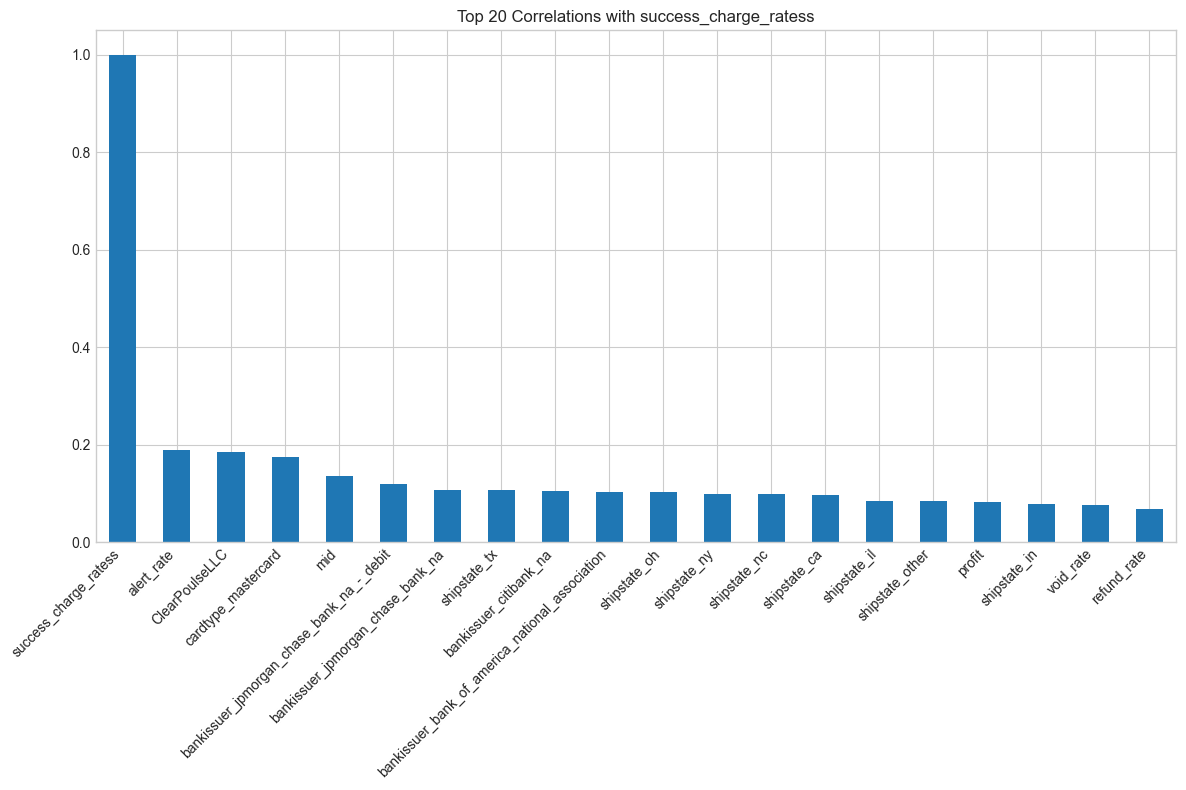

In [175]:
# Calculate correlations with success_charge_ratess, excluding date column
correlations = pooled_df_cleaned.drop('date', axis=1).corr()['success_charge_ratess'].sort_values(ascending=False)

# Display all correlations
print("Correlations with success_charge_ratess:")
print(correlations)

# Create a figure to visualize top correlations
plt.figure(figsize=(12, 8))
correlations.head(20).plot(kind='bar')
plt.title('Top 20 Correlations with success_charge_ratess')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [176]:
import numpy as np
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import matplotlib.pyplot as plt

# Prepare data for modeling - remove non-numeric columns
exclude_cols = ['date', 'mid']
X_train_numeric = X_train.drop(columns=[col for col in exclude_cols if col in X_train.columns], errors='ignore')
X_val_numeric = X_val.drop(columns=[col for col in exclude_cols if col in X_val.columns], errors='ignore')  
X_test_numeric = X_test.drop(columns=[col for col in exclude_cols if col in X_test.columns], errors='ignore')

X_train_numeric = X_train_numeric.select_dtypes(include=[np.number])
X_val_numeric = X_val_numeric.select_dtypes(include=[np.number])
X_test_numeric = X_test_numeric.select_dtypes(include=[np.number])

print(f"Final numeric features: {X_train_numeric.shape[1]}")
print(f"Train shape: {X_train_numeric.shape}")
print(f"Val shape: {X_val_numeric.shape}")
print(f"Test shape: {X_test_numeric.shape}")

# Initialize results dictionary
results = {}

Final numeric features: 76
Train shape: (4364, 76)
Val shape: (891, 76)
Test shape: (1047, 76)


In [177]:
# Setup for hyperparameter tuning using validation set
from sklearn.model_selection import PredefinedSplit
split_index = [-1] * len(X_train_numeric) + [0] * len(X_val_numeric)
X_train_val = pd.concat([X_train_numeric, X_val_numeric])
y_train_val = np.concatenate([y_train, y_val])
ps = PredefinedSplit(split_index)

print("Setup complete for hyperparameter tuning")

Setup complete for hyperparameter tuning


In [178]:
# 2. Lasso Regression
print("\\n" + "=" * 60)
print("TRAINING LASSO MODEL")
print("=" * 60)

lasso_param_grid = {
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(random_state=42, max_iter=2000))
])

lasso_grid_search = GridSearchCV(
    lasso_pipe, 
    lasso_param_grid, 
    cv=ps, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1, 
    verbose=1
)

print("Fitting Lasso...")
lasso_grid_search.fit(X_train_val, y_train_val)

# Get best model and make predictions
lasso_best_model = lasso_grid_search.best_estimator_
lasso_pred = lasso_best_model.predict(X_test_numeric)

# Calculate metrics
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

# Get feature selection info
lasso_coefs = lasso_best_model.named_steps['model'].coef_
non_zero_features = np.sum(lasso_coefs != 0)

print(f"\\nLasso Results:")
print(f"Best params: {lasso_grid_search.best_params_}")
print(f"MAE: {lasso_mae:.4f}")
print(f"R2: {lasso_r2:.4f}")
print(f"RMSE: {lasso_rmse:.4f}")
print(f"Features selected: {non_zero_features}/{len(lasso_coefs)}")

# Print feature coefficients
print("\nFeature coefficients:")
feature_names = X_train_numeric.columns
for name, coef in zip(feature_names, lasso_coefs):
    if coef != 0:  # Only show non-zero coefficients
        print(f"{name}: {coef:.4f}")

results['Lasso'] = {
    'model': lasso_best_model,
    'predictions': lasso_pred,
    'mae': lasso_mae,
    'r2': lasso_r2,
    'rmse': lasso_rmse,
    'features_selected': non_zero_features,
    'coefficients': dict(zip(feature_names, lasso_coefs))
}

\n============================================================
TRAINING LASSO MODEL
Fitting Lasso...
Fitting 1 folds for each of 6 candidates, totalling 6 fits
\nLasso Results:
Best params: {'model__alpha': 0.001}
MAE: 0.1048
R2: 0.5505
RMSE: 0.1641
Features selected: 51/76

Feature coefficients:
cycle_1_decline: -0.1651
renewal_decline: -0.0004
renewal_success_rate: 0.0007
adjustments: 0.0036
refund_rate: 0.0096
refunded_revenue: 0.0025
voids: 0.0042
void_rate: 0.0086
alert_rate: 0.0355
cost_of_revenue: 0.0709
chargeback_fees_rate: 0.0068
profit: 0.1358
SpecifiConLLC: -0.0019
DiamondSphereLLC: 0.0031
PrimeSmartSolutionsLLC: 0.0018
ClearPoulseLLC: 0.0175
BrightAdvantageLLC: -0.0012
BrightAdvantagellc: -0.0020
charge_dp1_v1: -0.0015
cardtype_visa: -0.0132
cardtype_mastercard: 0.0024
dayofweek_thursday: 0.0002
dayofweek_monday: -0.0011
dayofweek_sunday: -0.0008
dayofweek_saturday: -0.0014
dayofweek_friday: 0.0014
bankissuer_jpmorgan_chase_bank_na: 0.0101
bankissuer_other: 0.0096
bankissu

In [179]:
# =========================
# XGBOOST (leakage-safe)
# =========================
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# --- Assumes you already have these ready: ---
# X_train_numeric, y_train
# X_val_numeric,   y_val
# X_test_numeric,  y_test
# If not, build the PredefinedSplit and the combined train+val now:

# Make sure columns line up between train/val/test
common_cols = X_train_numeric.columns.intersection(X_val_numeric.columns).intersection(X_test_numeric.columns)
X_train_numeric = X_train_numeric[common_cols].copy()
X_val_numeric   = X_val_numeric[common_cols].copy()
X_test_numeric  = X_test_numeric[common_cols].copy()

# Combine train+val for GridSearch with a fixed validation fold
X_train_val = pd.concat([X_train_numeric, X_val_numeric], axis=0)
y_train_val = np.concatenate([y_train, y_val])

# PredefinedSplit: -1 = train fold, 0 = validation fold
split_index = np.array([-1] * len(X_train_numeric) + [0] * len(X_val_numeric))
ps = PredefinedSplit(test_fold=split_index)

print("\n" + "=" * 60)
print("TRAINING XGBOOST MODEL")
print("=" * 60)

# Parameter grid (compact but useful)
xgb_param_grid = {
    'model__n_estimators':      [200, 400],
    'model__max_depth':         [3, 5, 7],
    'model__learning_rate':     [0.05, 0.1],
    'model__subsample':         [0.8, 1.0],
    'model__colsample_bytree':  [0.8, 1.0],
    'model__reg_lambda':        [1.0, 5.0],   # L2
    'model__reg_alpha':         [0.0, 1.0],   # L1
}

# Pipeline (no scaler needed for trees)
from sklearn.pipeline import Pipeline
xgb_pipe = Pipeline([
    ('model', XGBRegressor(
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror',   # explicit for regression
        tree_method='hist'              # faster on larger data
    ))
])

# Grid search using the predefined train/val split
xgb_grid = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=xgb_param_grid,
    cv=ps,                              # use our fixed validation split
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

print("Fitting XGBoost...")
xgb_grid.fit(X_train_val, y_train_val)

# Best model
xgb_best = xgb_grid.best_estimator_

# Predict on test
xgb_pred = xgb_best.predict(X_test_numeric)

# Metrics
xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_mse  = mean_squared_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2   = r2_score(y_test, xgb_pred)

print("\nXGBoost Results:")
print(f"Best params: {xgb_grid.best_params_}")
print(f"MAE : {xgb_mae:.6f}")
print(f"RMSE: {xgb_rmse:.6f}")
print(f"R²  : {xgb_r2:.6f}")

# Feature importances (gain-based). Columns align with common_cols above.
importances = xgb_best.named_steps['model'].feature_importances_
feat_imp = pd.DataFrame({'feature': common_cols, 'importance': importances}) \
             .sort_values('importance', ascending=False)

print("\nTop 20 feature importances:")
print(feat_imp.head(20).to_string(index=False))

# Optional: stash results in a dict for later comparison
results = locals().get('results', {})
results['XGBoost'] = {
    'model': xgb_best,
    'predictions': xgb_pred,
    'mae': xgb_mae,
    'rmse': xgb_rmse,
    'r2': xgb_r2,
    'best_params': xgb_grid.best_params_,
    'feature_importance': feat_imp
}



TRAINING XGBOOST MODEL
Fitting XGBoost...
Fitting 1 folds for each of 192 candidates, totalling 192 fits

XGBoost Results:
Best params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 400, 'model__reg_alpha': 0.0, 'model__reg_lambda': 1.0, 'model__subsample': 0.8}
MAE : 0.002963
RMSE: 0.008114
R²  : 0.998901

Top 20 feature importances:
             feature  importance
     cycle_1_decline    0.531027
              profit    0.233253
         adjustments    0.132423
     cost_of_revenue    0.053314
          alert_rate    0.014762
chargeback_fees_rate    0.014551
       cardtype_visa    0.003806
       charge_dp1_v1    0.002552
               voids    0.001573
         refund_rate    0.001385
     shipstate_other    0.001246
  dayofweek_thursday    0.001011
           void_rate    0.000821
    refunded_revenue    0.000801
  dayofweek_saturday    0.000778
 cardtype_mastercard    0.000750
    bankissuer_other    0.000653
    d

In [182]:
# =========================
# RANDOM FOREST (regression)
# =========================
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

print("\n" + "=" * 60)
print("TRAINING RANDOM FOREST MODEL")
print("=" * 60)

# Ensure consistent columns across splits
common_cols = X_train_numeric.columns.intersection(X_val_numeric.columns).intersection(X_test_numeric.columns)
X_train_numeric = X_train_numeric[common_cols].copy()
X_val_numeric   = X_val_numeric[common_cols].copy()
X_test_numeric  = X_test_numeric[common_cols].copy()

# Combine train+val for GridSearch with a fixed validation fold
X_train_val = pd.concat([X_train_numeric, X_val_numeric], axis=0)
y_train_val = np.concatenate([y_train, y_val])

# PredefinedSplit: -1 = train, 0 = validation (constructed earlier as `ps`)
# If you need to build it here:
# split_index = np.array([-1] * len(X_train_numeric) + [0] * len(X_val_numeric))
# ps = PredefinedSplit(test_fold=split_index)

# --- RF pipeline (no scaler needed for trees) ---
rf_pipe = Pipeline([
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# --- Hyperparameter grid ---
rf_param_grid = {
    'model__n_estimators': [200, 400, 800],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 0.5, 1.0],  # try sqrt or fractions
}

# --- Grid search using the predefined train/val split ---
rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    cv=ps,  # your PredefinedSplit
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

print("Fitting Random Forest...")
rf_grid.fit(X_train_val, y_train_val)

# Best model
rf_best = rf_grid.best_estimator_

# Predict on held-out test set
rf_pred  = rf_best.predict(X_test_numeric)

# Metrics
rf_mae   = mean_absolute_error(y_test, rf_pred)
rf_mse   = mean_squared_error(y_test, rf_pred)
rf_rmse  = np.sqrt(rf_mse)
rf_r2    = r2_score(y_test, rf_pred)

print("\nRandom Forest Results:")
print(f"Best params: {rf_grid.best_params_}")
print(f"MAE : {rf_mae:.6f}")
print(f"RMSE: {rf_rmse:.6f}")
print(f"R²  : {rf_r2:.6f}")

# --- Feature importance table ---
feat_imp = pd.DataFrame({
    'feature': common_cols,
    'importance': rf_best.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False)

# Pretty print top features
TOP_N = 25
print("\nTop feature importances:")
print(feat_imp.head(TOP_N).to_string(index=False, formatters={'importance': '{:,.6f}'.format}))

# (Optional) Save the table if you want a file
# feat_imp.to_csv("rf_feature_importance.csv", index=False)

# Stash in results dict (if you're collecting models)
results = locals().get('results', {})
results['RandomForest'] = {
    'model': rf_best,
    'predictions': rf_pred,
    'mae': rf_mae,
    'rmse': rf_rmse,
    'r2': rf_r2,
    'best_params': rf_grid.best_params_,
    'feature_importance': feat_imp
}



TRAINING RANDOM FOREST MODEL
Fitting Random Forest...
Fitting 1 folds for each of 324 candidates, totalling 324 fits

Random Forest Results:
Best params: {'model__max_depth': None, 'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 800}
MAE : 0.003165
RMSE: 0.010976
R²  : 0.997988

Top feature importances:
             feature importance
     cycle_1_decline   0.673797
              profit   0.219112
     cost_of_revenue   0.053163
         adjustments   0.043851
          alert_rate   0.006405
chargeback_fees_rate   0.001870
           void_rate   0.000274
         refund_rate   0.000122
    bankissuer_other   0.000112
  BrightAdvantageLLC   0.000107
  dayofweek_saturday   0.000098
  dayofweek_thursday   0.000092
   dayofweek_tuesday   0.000088
 cardtype_mastercard   0.000086
       cardtype_visa   0.000083
     shipstate_other   0.000078
    dayofweek_friday   0.000077
    dayofweek_monday   0.000063
       SpecifiConLLC  

In [185]:
# Calculate correlations between target and other numeric columns, excluding date
correlations = pooled_df_cleaned.select_dtypes(include=['float64', 'int64']).corr()['success_charge_ratess'].sort_values(ascending=False)

# Display correlations
print("\nCorrelations with target variable:")
print(correlations)


Correlations with target variable:
success_charge_ratess                        1.000000
alert_rate                                   0.188074
ClearPoulseLLC                               0.185633
cardtype_mastercard                          0.175282
bankissuer_jpmorgan_chase_bank_na_-_debit    0.119475
                                               ...   
processor_quant_cbsl                              NaN
processor_cbc                                     NaN
processor_syn                                     NaN
processor_psf_bbva                                NaN
processor_71_psf                                  NaN
Name: success_charge_ratess, Length: 74, dtype: float64
